Este *notebook* es la contuación de TFM-EDA y contiene el preprocesamiento de los datasets, el modelado y la evaluación.

In [24]:
# Importar librerías necesarias
import os, sys, re, calendar, itertools
import time as time_module
from datetime import datetime, date, timedelta, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_white

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

from prophet import Prophet
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

# Comprobar que detecta la GPU
physical_devices = tf.config.experimental.list_physical_devices("GPU")
print("Physical GPUs available: ", len(physical_devices))
print(physical_devices)

Physical GPUs available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
def week_of_month(series):
    """
    Devuelve la semana del mes (1-n) a la que pertenece una fecha.

    Args:
        - series (pd.Series): Serie de fechas (datetime64[ns]).

    Returns:
        - pd.Series: Semana del mes como enteros (1 = primera).
    """
    day = series.dt.day
    first_day_month = series - pd.to_timedelta(day - 1, unit="D")  # Primer día del mes
    offset = first_day_month.dt.weekday  # 0 = lunes, 6 = domingo
    return np.ceil((day + offset) / 7).astype(int)

In [26]:
def get_season(series):
    """
    Clasifica cada fecha en su estación del año según fechas fijas
    de cambio estacional (21 de marzo, junio, septiembre y diciembre).

    Args:
        - series (pd.Series): Serie de tipo datetime64[ns].

    Returns:
        - pd.Series: Serie de enteros con la estación correspondiente:
            - 0: primavera
            - 1: verano
            - 2: otoño
            - 3: invierno
    """
    # Año de cada fecha
    years = series.dt.year

    # Crear fechas límite para cada estación
    spring = pd.to_datetime(years.astype(str) + "-03-21")
    summer = pd.to_datetime(years.astype(str) + "-06-21")
    autumn = pd.to_datetime(years.astype(str) + "-09-21")
    winter = pd.to_datetime(years.astype(str) + "-12-21")

    # Inicializar con "invierno"
    season = pd.Series(3, index=series.index)

    # Asignar estaciones por condiciones vectorizadas
    season[(series >= spring) & (series < summer)] = 0
    season[(series >= summer) & (series < autumn)] = 1
    season[(series >= autumn) & (series < winter)] = 2
    # Las demás fechas siguen siendo "invierno"

    return season

In [27]:
def create_lagged_features(data, to_lag, drop_original=False):
    """
    Genera variables rezagadas (lags) para las columnas especificadas de un DataFrame.

    Args:
        - data (pd.DataFrame): DataFrame que contiene las series temporales originales.
        - to_lag (dict): Diccionario con el formato {columna: [lags]} que indica 
            los rezagos (desplazamientos hacia atrás) que se aplicarán a cada columna.
        - drop_original (bool, opcional): Si es True, elimina las columnas originales
            que se han utilizado para generar las variables rezagadas. 
            Por defecto es False.

    Returns:
        tuple:
            - pd.DataFrame: DataFrame con las nuevas columnas *_lagN*.
            - list: Lista con los nombres de las columnas generadas.
    """
    df = data.copy()
    lagged_cols = []
    
    for col, lags in to_lag.items():
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
            lagged_cols.append(f"{col}_lag{lag}")
            
    if drop_original:
        df.drop(columns=list(to_lag.keys()), inplace=True)
    
    return df, lagged_cols

In [28]:
def cyclical_features(df_raw, include_slot=True):
    """
    Genera variables cíclicas y de horario a partir de una columna temporal "datetime"
    y del día de la semana, codificando la naturaleza periódica del tiempo.

    Se añaden representaciones senoidales y cosenoidales para la hora y el día de la semana,
    junto con variables binarias que identifican tramos típicos de apertura (tarde/noche).

    Args:
        - df_raw (pd.DataFrame): DataFrame con una columna "datetime" y "dia_semana".
        - include_slot (bool): Si True, agrega la columna "tramo" (entero 0–47).

    Returns:
        - pd.DataFrame: Copia del DataFrame original con nuevas columnas:
              - tramo (opcional)
              - hora_sin, hora_cos
              - ds_sin, ds_cos
              - abierto_tarde, abierto_noche
    """
    df = df_raw.copy()

    # Tramos de 30 min codificados en enteros 0-47
    slot = df["datetime"].dt.hour * 2 + df["datetime"].dt.minute // 30

    if include_slot:
        df["tramo"] = slot

    # Codificación cíclica
    df["hora_sin"] = np.sin(2 * np.pi * slot / 48).astype("float32")
    df["hora_cos"] = np.cos(2 * np.pi * slot / 48).astype("float32")
    df["ds_sin"] = np.sin(2 * np.pi * df["dia_semana"] / 7).astype("float32")
    df["ds_cos"] = np.cos(2 * np.pi * df["dia_semana"] / 7).astype("float32")

    # Variables de horario de apertura: aprox. 13:00-16:00 y 19:00-00:00
    df["abierto_tarde"] = slot.between(26, 32).astype("int32")                     # 13:00 -> 26; 16:00 -> 32
    df["abierto_noche"] = ((slot.between(38, 47)) | (slot == 0)).astype("int32")   # 19:00 -> 38; 00:00 -> 0
    
    return df

In [29]:
def strip_prefix(params, prefix="estimator__"):
    """
    Elimina un prefijo común de las claves de un diccionario de parámetros.

    Útil para limpiar nombres de parámetros anidados (por ejemplo, los generados por
    "GridSearchCV" con pipelines de scikit-learn).

    Args:
        - params (dict): Diccionario de parámetros con claves prefijadas.
        - prefix (str): Prefijo a eliminar (por defecto: "estimator__").

    Returns:
        - dict: Nuevo diccionario con las claves sin el prefijo especificado.
    """
    return {k.replace(prefix, ""): v for k, v in params.items()}

In [30]:
def metrics_from_results(data, label, mode, schedule_filter=True):
    """
    Calcula una métrica por folds y franjas para las variables "tot" y "dom" a partir de
    un DataFrame con columnas *_true y *_predict. Opcionalmente segmenta por franjas
    "tarde" y "noche" usando 'abierto_tarde' y 'abierto_noche'.

    Métricas soportadas:
        - mode="mae"      : MAE, redondeado a 4 decimales.
        - mode="rel_err"  : Error relativo medio en %, definido como mean(|yhat - y| / |y| * 100),
                            ignorando observaciones con y==0 (se tratan como NaN).
        - mode="mape"     : Alias de "rel_err".

    Args:
        data (pd.DataFrame): DataFrame con columnas 'tot_*_true', 'tot_*_predict',
                             'dom_*_true' y 'dom_*_predict', y la columna 'fold'.
        label (str): Etiqueta informativa (p. ej., "TRAIN" o "TEST"). No afecta al cálculo,
                     pero el índice de filas se nombra como 'label' para reflejarlo.
        schedule_filter (bool): Si True, calcula métricas por "tarde" y "noche".
                                Si False, calcula una única franja "global".

    Returns:
        pd.DataFrame:
            - Filas: MultiIndex con dos niveles:
                * Nivel 0 (nombre: "label"): valores {"tot","dom"}
                * Nivel 1 (nombre: "franja"): {"global"} o {"tarde","noche"} según schedule_filter
            - Columnas: cada fold presente en 'data["fold"]' y una columna adicional "global"
                        (cálculo sobre todos los folds combinados para esa franja).
            - Valores: métrica seleccionada, redondeada a 4 decimales.

    Note:
        - Se asume que existe exactamente una columna *_true y una *_predict por variable ("tot"/"dom").
        - Si schedule_filter=True, se requieren las columnas 'abierto_tarde' y 'abierto_noche' casteables a bool.
        - Se requiere la columna 'fold' para construir las columnas por fold.
    """
    get_col = lambda prefix, suffix: [c for c in data if re.match(rf"^{prefix}.*_{suffix}$", c)][0]

    mode_l = str(mode).lower()
    if mode_l == "mae":
        metric = lambda y, ypred: round(mean_absolute_error(y, ypred), 4)
    elif mode_l in ("rel_err", "mape"):
        def metric(y, ypred):
            y = np.asarray(y, dtype=float)
            ypred = np.asarray(ypred, dtype=float)
            # Ignorar casos con y==0 en el promedio
            denom = np.where(y != 0.0, np.abs(y), np.nan)
            if np.isnan(denom).all():
                return float("nan")
            rel = np.abs(ypred - y) / denom * 100.0
            return round(np.nanmean(rel), 4)
    else:
        raise ValueError(f"mode debe ser 'mae' o 'rel_err' (alias: 'mape'). Recibido: {mode!r}")

    if "fold" not in data.columns:
        raise ValueError("La columna 'fold' es obligatoria para calcular métricas por fold.")

    tot_true, tot_pred = get_col("tot", "true"), get_col("tot", "predict")
    dom_true, dom_pred = get_col("dom", "true"), get_col("dom", "predict")

    if schedule_filter:
        if "abierto_tarde" not in data or "abierto_noche" not in data:
            raise ValueError("schedule_filter=True requiere 'abierto_tarde' y 'abierto_noche'.")
        masks_franja = {
            "tarde": data["abierto_tarde"].astype(bool),
            "noche": data["abierto_noche"].astype(bool),
        }
        filas = ["tarde", "noche"]
    else:
        masks_franja = {"global": pd.Series(True, index=data.index)}
        filas = ["global"]

    folds = sorted(data["fold"].unique())
    cols = folds + ["global"]

    df_tot = pd.DataFrame(index=filas, columns=cols, dtype=float)
    df_dom = pd.DataFrame(index=filas, columns=cols, dtype=float)

    for franja, m_franja in masks_franja.items():
        # Por fold
        for f in folds:
            m = (data["fold"] == f) & m_franja
            df_tot.loc[franja, f] = metric(data.loc[m, tot_true], data.loc[m, tot_pred]) if m.any() else float("nan")
            df_dom.loc[franja, f] = metric(data.loc[m, dom_true], data.loc[m, dom_pred]) if m.any() else float("nan")
        # Global (todos los folds de la franja)
        m_all = m_franja
        df_tot.loc[franja, "global"] = metric(data.loc[m_all, tot_true], data.loc[m_all, tot_pred]) if m_all.any() else float("nan")
        df_dom.loc[franja, "global"] = metric(data.loc[m_all, dom_true], data.loc[m_all, dom_pred]) if m_all.any() else float("nan")

    out = pd.concat({"tot": df_tot, "dom": df_dom})
    out.index.set_names([label, "franja"], inplace=True)
    return out

In [31]:
def train_tree(data, target_cols, feature_cols, model, splits):
    """
    Entrena un modelo tipo árbol sobre múltiples divisiones (splits) y recopila
    las predicciones y valores reales para train y test en cada fold.

    Cada división se entrena con un clon independiente del modelo original
    para evitar fugas de información entre folds.

    Args:
        - data (pd.DataFrame): Dataset completo con las variables de entrada y salida.
        - target_cols (list[str]): Columnas objetivo en orden (["total_pedidos", "domicilio"]).
        - feature_cols (list[str]): Columnas de características utilizadas para entrenar.
        - model (sklearn): Modelo compatible con scikit-learn.
        - splits (iterable): Lista o generador de tuplas (train_idx, test_idx)
                             con los índices de cada fold.

    Returns:
        - tuple(pd.DataFrame, pd.DataFrame):
            * **train_df**: DataFrame con las predicciones y valores reales de entrenamiento,
              incluyendo las columnas:
                - fold
                - tot_train_true, dom_train_true
                - tot_train_predict, dom_train_predict

            * **test_df**: DataFrame con las predicciones y valores reales de prueba,
              incluyendo las columnas:
                - fold
                - tot_test_true, dom_test_true
                - tot_test_predict, dom_test_predict
              
              Ambos DataFrames conservan el índice original de las observaciones.
    """
    df = data.copy()

    # Contenedores de predicciones
    tot_train_predict, tot_test_predict = [], []
    dom_train_predict, dom_test_predict = [], []

    # Contenedores de datos reales
    tot_train_true, tot_test_true = [], []
    dom_train_true, dom_test_true = [], []

    # Contenedores de índices
    train_index, test_index = [], []

    # Contenedores de folds
    train_fold, test_fold = [], []

    for fold_idx, (tr, ts) in enumerate(splits, start=1):
        # Train y test
        X_train, Y_train = df.iloc[tr][feature_cols], df.iloc[tr][target_cols].to_numpy()
        X_test, Y_test = df.iloc[ts][feature_cols], df.iloc[ts][target_cols].to_numpy()

        # Modelo (clon virgen por split)
        mdl = clone(model) # Se conserva el modelo virgen para cada set de splits

        # Entrenar
        mdl.fit(X_train, Y_train)

        # Predecir
        train_predict = mdl.predict(X_train)
        test_predict = mdl.predict(X_test)

        # Extender contenedores (asumiendo target_cols = [tot, dom] en ese orden)
        tot_train_predict.extend(train_predict[:, 0])
        dom_train_predict.extend(train_predict[:, 1])
        
        tot_test_predict.extend(test_predict[:, 0])
        dom_test_predict.extend(test_predict[:, 1])

        # Añadir datos reales
        tot_train_true.extend(Y_train[:, 0])
        dom_train_true.extend(Y_train[:, 1])

        tot_test_true.extend(Y_test[:, 0])
        dom_test_true.extend(Y_test[:, 1])

        # Guardar índices originales
        train_index.extend(df.iloc[tr].index.tolist())
        test_index.extend(df.iloc[ts].index.tolist())

        # Guardar el fold
        train_fold.extend([fold_idx] * len(train_predict[:, 0]))
        test_fold.extend([fold_idx] * len(test_predict[:, 0]))

    return (
        pd.DataFrame(
            data={
                # Train
                "fold":              np.array(train_fold),
                "tot_train_true":    np.array(tot_train_true),
                "dom_train_true":    np.array(dom_train_true),
                "tot_train_predict": np.array(tot_train_predict),
                "dom_train_predict": np.array(dom_train_predict)
            },
            index=pd.Index(np.array(train_index), name="index")
        ),
        pd.DataFrame(
            data={
                # Test
                "fold":             np.array(test_fold),
                "tot_test_true":    np.array(tot_test_true),
                "dom_test_true":    np.array(dom_test_true),
                "tot_test_predict": np.array(tot_test_predict),
                "dom_test_predict": np.array(dom_test_predict)
            },
            index=pd.Index(np.array(test_index), name="index")
        )
    )

In [32]:
def create_sequences(X_raw, y_raw, look_back):
    """
    Construye secuencias temporales (ventanas deslizantes) para el entrenamiento de modelos RNN.

    Cada muestra de entrada incluye los últimos "look_back" registros de X, y la salida
    corresponde al valor siguiente en y. Útil para modelar dependencias temporales.

    Args:
        - X_raw (pd.DataFrame): Variables explicativas ordenadas temporalmente.
        - y_raw (pd.DataFrame): Variables objetivo alineadas con X_raw.
        - look_back (int): Longitud de la secuencia (número de pasos atrás).

    Returns:
        - tuple(np.ndarray, np.ndarray):
            * **Xs**: Secuencias de entrada con forma (n_samples, look_back, n_features).
            * **ys**: Valores objetivo correspondientes con forma (n_samples, n_targets).
    """
    X = X_raw.to_numpy()
    y = y_raw.to_numpy()
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:i+look_back])
        ys.append(y[i+look_back])
    return np.array(Xs), np.array(ys)


def build_rnn_model(cell, rnn_layers, look_back, n_features, n_targets, dropout, l2_reg=1e-6):
    """
    Construye y compila un modelo RNN secuencial (LSTM o GRU) con arquitectura configurable.

    Se crean múltiples capas recurrentes con dropout opcional y regularización L2.
    La capa de salida usa activación "softplus" para mantener valores positivos.

    Args:
        - cell (str): Tipo de celda recurrente ("lstm" o "gru").
        - rnn_layers (list[int]): Unidades por capa recurrente (define la profundidad del modelo).
        - look_back (int): Longitud de la secuencia de entrada (tamaño de ventana temporal).
        - n_features (int): Número de variables de entrada por timestep.
        - n_targets (int): Número de variables objetivo de salida.
        - dropout (float): Tasa de dropout entre capas recurrentes.
        - l2_reg (float): Factor de regularización L2 (por defecto 1e-6).

    Returns:
        - keras.models.Sequential: Modelo RNN compilado con pérdida MAE y optimizador Adam.
    """
    RNN = {"lstm": LSTM, "gru": GRU}[cell.lower()]
    layers = []
    for i, n in enumerate(rnn_layers):
        if i == 0 and len(rnn_layers) > 1:           # Primera capa
            layers.append(RNN(n, return_sequences=True, input_shape=(look_back, n_features), kernel_regularizer=l2(l2_reg)))
            layers.append(Dropout(dropout))
            
        elif i == len(rnn_layers) - 1:                # Última capa
            layers.append(RNN(n, return_sequences=False, kernel_regularizer=l2(l2_reg)))
            #layers.append(Dropout(dropout))
            #layers.append(Dense(4))
            layers.append(Dense(n_targets, activation="softplus", kernel_regularizer=l2(l2_reg*0.1)))  # "softplus" o "relu"
        else:                                          # Capas intermedias
            layers.append(RNN(n, return_sequences=True, kernel_regularizer=l2(l2_reg)))
            layers.append(Dropout(dropout))
            
    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="mae",
                  metrics=["mae"])
    
    return model


def train_rnn(data, target_cols, feature_cols, scale_cols, params, scaler_class, splits):
    """
    Entrena una red recurrente (LSTM/GRU) sobre múltiples divisiones (splits),
    generando las predicciones y valores reales para train, validation y test en cada fold.

    En cada iteración se crean nuevos escaladores y un modelo independiente, evitando
    fugas de información entre particiones. Las secuencias se construyen mediante la
    ventana temporal definida por "look_back".

    Args:
        - data (pd.DataFrame): Dataset completo con las variables de entrada y salida.
        - target_cols (list[str]): Columnas objetivo en orden (["total_pedidos", "domicilio"]).
        - feature_cols (list[str]): Columnas de características utilizadas para entrenar.
        - scale_cols (list[str] | None): Columnas que serán escaladas (None para omitir escalado).
        - params (dict): Parámetros del modelo y configuración temporal, que deben incluir:
              - "rnn_type" (str): Tipo de celda recurrente ("LSTM" o "GRU").
              - "rnn_layers" (int): Número de capas recurrentes.
              - "look_back" (int): Longitud de la ventana temporal (tamaño de secuencia).
              - "dropout" (float): Tasa de dropout aplicada entre capas.
        - scaler_class (type): Clase del escalador (por ejemplo, "MinMaxScaler" o "StandardScaler").
        - splits (iterable): Lista o generador de tuplas (train_idx, val_idx, test_idx)
                             con los índices de cada fold.

    Returns:
        - tuple(pd.DataFrame, pd.DataFrame, pd.DataFrame):
            * **train_df**: DataFrame con predicciones y valores reales de entrenamiento,
              incluyendo:
                - fold
                - tot_train_true, dom_train_true
                - tot_train_predict, dom_train_predict

            * **val_df**: DataFrame con resultados de validación,
              incluyendo:
                - fold
                - tot_val_true, dom_val_true
                - tot_val_predict, dom_val_predict

            * **test_df**: DataFrame con resultados de prueba,
              incluyendo:
                - fold
                - tot_test_true, dom_test_true
                - tot_test_predict, dom_test_predict

              Los tres DataFrames conservan el índice original de las observaciones y
              permiten analizar el desempeño del modelo por fold.
    """
    df = data.copy()

    cell = params["rnn_type"]
    rnn_layers = params["rnn_layers"]
    look_back = params["look_back"]
    n_features = len(feature_cols)
    n_targets = len(target_cols)
    dropout = params["dropout"]

    # Contenedores de predicciones
    tot_train_predict, tot_val_predict, tot_test_predict = [], [], []
    dom_train_predict, dom_val_predict, dom_test_predict = [], [], []

    # Contenedores de datos reales
    tot_train_true, tot_val_true, tot_test_true = [], [], []
    dom_train_true, dom_val_true, dom_test_true = [], [], []

    # Contenedores de índices
    train_index, val_index, test_index = [], [], []

    # Contenedores de folds
    train_fold, val_fold, test_fold = [], [], []

    for fold_idx, (tr, val, ts) in enumerate(splits, start=1):
        # Train, validation y test
        X_train, Y_train = df.iloc[tr][feature_cols], df.iloc[tr][target_cols]
        X_val, Y_val = df.iloc[val][feature_cols], df.iloc[val][target_cols]
        X_test, Y_test = df.iloc[ts][feature_cols], df.iloc[ts][target_cols]

        # Preparar datasets para escalar
        X_train_scaled, Y_train_scaled = X_train.copy(), Y_train.copy()
        X_val_scaled, Y_val_scaled = X_val.copy(), Y_val.copy()
        X_test_scaled, Y_test_scaled = X_test.copy(), Y_test.copy()

        # Escaladores nuevos en cada iteración
        x_scaler = scaler_class()
        y_scaler = scaler_class()

        if scale_cols:
            sc = [col for col in scale_cols if col in feature_cols]
            if sc:
                # Escalar las columnas deseadas
                X_train_scaled[sc] = x_scaler.fit_transform(X_train[sc])
                X_val_scaled[sc] = x_scaler.transform(X_val[sc])
                X_test_scaled[sc] = x_scaler.transform(X_test[sc])

        # Escalar siempre las targets
        Y_train_scaled[target_cols] = y_scaler.fit_transform(Y_train[target_cols])
        Y_val_scaled[target_cols] = y_scaler.transform(Y_val[target_cols])
        Y_test_scaled[target_cols] = y_scaler.transform(Y_test[target_cols])

        # Construir secuencias con "look_back"
        X_train_seq, Y_train_seq = create_sequences(X_train_scaled, Y_train_scaled, look_back)
        X_val_seq, Y_val_seq = create_sequences(X_val_scaled, Y_val_scaled, look_back)
        X_test_seq, Y_test_seq = create_sequences(X_test_scaled, Y_test_scaled, look_back)

        # Construir modelo
        model = build_rnn_model(cell, rnn_layers, look_back, n_features, n_targets, dropout)
        early_stopping = EarlyStopping(
            monitor="val_mae",
            mode="min",
            patience=8,
            min_delta=0.001,
            restore_best_weights=True
        )

        # Entrenar modelo
        model.fit(
            X_train_seq, Y_train_seq,
            epochs=50,
            batch_size=64,
            validation_data=(X_val_seq, Y_val_seq),
            callbacks=[early_stopping],
            verbose=0
        )

        # Predecir
        train_predict = y_scaler.inverse_transform(model.predict(X_train_seq))
        val_predict = y_scaler.inverse_transform(model.predict(X_val_seq))
        test_predict = y_scaler.inverse_transform(model.predict(X_test_seq))

        # Extender contenedores (asumiendo target_cols = [tot, dom] en ese orden)
        tot_train_predict.extend(train_predict[:, 0])
        tot_val_predict.extend(val_predict[:, 0])
        tot_test_predict.extend(test_predict[:, 0])

        dom_train_predict.extend(train_predict[:, 1])
        dom_val_predict.extend(val_predict[:, 1])
        dom_test_predict.extend(test_predict[:, 1])

        # Añadir datos reales
        tot_train_true.extend(Y_train.iloc[look_back:, 0])
        tot_val_true.extend(Y_val.iloc[look_back:, 0])
        tot_test_true.extend(Y_test.iloc[look_back:, 0])

        dom_train_true.extend(Y_train.iloc[look_back:, 1])
        dom_val_true.extend(Y_val.iloc[look_back:, 1])
        dom_test_true.extend(Y_test.iloc[look_back:, 1])

        # Guardar índices originales
        train_index.extend(Y_train.index.tolist()[look_back:]) # `Y_train` es reemplazable por `df.iloc[tr]`
        val_index.extend(Y_val.index.tolist()[look_back:])     # `Y_val` es reemplazable por `df.iloc[val]`
        test_index.extend(Y_test.index.tolist()[look_back:])   # `Y_test` es reemplazable por `df.iloc[ts]`

        # Guardar el fold
        train_fold.extend([fold_idx] * len(train_predict[:, 0]))
        val_fold.extend([fold_idx] * len(val_predict[:, 0]))
        test_fold.extend([fold_idx] * len(test_predict[:, 0]))

    return (
    pd.DataFrame(
        data={
            # Train
            "fold":              np.array(train_fold),
            "tot_train_true":    np.array(tot_train_true),
            "dom_train_true":    np.array(dom_train_true),
            "tot_train_predict": np.array(tot_train_predict),
            "dom_train_predict": np.array(dom_train_predict)
        },
        index=pd.Index(np.array(train_index), name="index")
    ),
    pd.DataFrame(
        data={
            # Validation
            "fold":            np.array(val_fold),
            "tot_val_true":    np.array(tot_val_true),
            "dom_val_true":    np.array(dom_val_true),
            "tot_val_predict": np.array(tot_val_predict),
            "dom_val_predict": np.array(dom_val_predict)
        },
        index=pd.Index(np.array(val_index), name="index")
    ),
    pd.DataFrame(
        data={
            # Test
            "fold":             np.array(test_fold),
            "tot_test_true":    np.array(tot_test_true),
            "dom_test_true":    np.array(dom_test_true),
            "tot_test_predict": np.array(tot_test_predict),
            "dom_test_predict": np.array(dom_test_predict)
        },
        index=pd.Index(np.array(test_index), name="index")
    )
)

In [33]:
def train_hybrid(data, target_cols, feature_cols, base_model, splits, N_MA=32, S=336):
    """
    Entrena un modelo híbrido NaiveV2 + LightGBM sobre residuo para series con estacionalidad semanal.

    La idea es:
      1) Construir un perfil semanal NaiveV2 por franja (S=336) a partir del TRAIN (media de las últimas N_MA semanas).
      2) Generar predicciones Naive para TRAIN y TEST repitiendo ese perfil semanal.
      3) Calcular el residuo en TRAIN (Y_train - y_naive_train) y entrenar un modelo árbol (p.ej. LightGBM) sobre el residuo.
      4) Predecir el residuo en TRAIN/TEST y reconstruir la predicción final: y_pred = y_naive + residuo_pred.

    Args:
        - data (pd.DataFrame): DataFrame con features y targets.
        - target_cols (list[str]): Nombres de las columnas objetivo, en orden ["total_pedidos", "domicilio"].
        - feature_cols (list[str]): Nombres de las columnas de características para el árbol.
        - base_model (sklearn estimator): Estimador multi-output (p.ej. MultiOutputRegressor(LGBMRegressor(...))).
        - splits (list[tuple]): Lista de tuplas (train_idx, test_idx) con los índices de los pliegues temporales.
        - N_MA (int): Número de semanas para el promedio NaiveV2 por franja.
        - S (int): Tamaño de la semana en número de registros (por defecto, 48*7=336).

    Returns:
        tuple[pd.DataFrame, pd.DataFrame]:
            - df_train_res: DataFrame con predicciones y valores reales en TRAIN.
            - df_test_res:  DataFrame con predicciones y valores reales en TEST.

            Cada DataFrame incluye:
                - "fold": índice del pliegue temporal.
                - "*_train_true"/"*_test_true": valores reales.
                - "*_train_predict"/"*_test_predict": predicciones híbridas.
                - Índice alineado con los índices originales de data (según tr/ts).

    Notes:
        - El perfil NaiveV2 se calcula exclusivamente con Y_train de cada fold (sin fuga).
        - Si hay menos de N_MA semanas disponibles, se usa el máximo posible (>=1).
        - Asume que el horizonte de test es múltiplo de S para alineación por franja.
    """
    df = data.copy()

    # Contenedores de predicciones
    tot_train_predict, tot_test_predict = [], []
    dom_train_predict, dom_test_predict = [], []

    # Contenedores de datos reales
    tot_train_true, tot_test_true = [], []
    dom_train_true, dom_test_true = [], []

    # Contenedores de índices
    train_index, test_index = [], []

    # Contenedores de folds
    train_fold, test_fold = [], []

    def _weekly_profile(series, S, N_MA):
        """Perfil semanal NaiveV2 por franja: media de las últimas N_MA semanas (longitud S)."""
        n_weeks_avail = max(1, min(N_MA, len(series) // S))
        tail = series.iloc[-n_weeks_avail * S:]
        mat = np.array(tail).reshape(n_weeks_avail, S)
        return mat.mean(axis=0)  # shape: (S,)

    def _repeat_profile(profile, length):
        """Repite un perfil semanal para obtener un vector de longitud "length"."""
        reps = int(np.ceil(length / len(profile)))
        return np.tile(profile, reps)[:length]

    for fold_idx, (tr, ts) in enumerate(splits, start=1):
        # Particiones
        X_train = df.iloc[tr][feature_cols]
        X_test  = df.iloc[ts][feature_cols]
        Y_train = df.iloc[tr][target_cols]
        Y_test  = df.iloc[ts][target_cols]

        # Perfil Naive por target usando SOLO TRAIN
        naive_profiles = {}
        for col in target_cols:
            naive_profiles[col] = _weekly_profile(Y_train[col], S=S, N_MA=N_MA)  # (S,)

        # Predicciones Naive (train)
        y_naive_train = np.column_stack([
            _repeat_profile(naive_profiles[target_cols[0]], len(Y_train)),
            _repeat_profile(naive_profiles[target_cols[1]], len(Y_train))
        ])  # shape: (n_tr, 2)

        # Predicciones Naive (test)
        y_naive_test = np.column_stack([
            _repeat_profile(naive_profiles[target_cols[0]], len(Y_test)),
            _repeat_profile(naive_profiles[target_cols[1]], len(Y_test))
        ])  # shape: (n_ts, 2)

        # Residuo en TRAIN
        R_train = Y_train.to_numpy() - y_naive_train  # (n_tr, 2)

        # Modelo de residuo
        mdl = clone(base_model)  # Se conserva el modelo virgen por fold
        mdl.fit(X_train, R_train)

        # Predicción de residuo
        Rpred_train = mdl.predict(X_train)  # (n_tr, 2)
        Rpred_test  = mdl.predict(X_test)   # (n_ts, 2)

        # Predicción final híbrida
        ypred_train = y_naive_train + Rpred_train
        ypred_test  = y_naive_test + Rpred_test

        # Extender contenedores (asumiendo [tot, dom])
        tot_train_predict.extend(ypred_train[:, 0])
        dom_train_predict.extend(ypred_train[:, 1])

        tot_test_predict.extend(ypred_test[:, 0])
        dom_test_predict.extend(ypred_test[:, 1])

        # Añadir datos reales
        Y_train_np = Y_train.to_numpy()
        Y_test_np  = Y_test.to_numpy()

        tot_train_true.extend(Y_train_np[:, 0])
        dom_train_true.extend(Y_train_np[:, 1])

        tot_test_true.extend(Y_test_np[:, 0])
        dom_test_true.extend(Y_test_np[:, 1])

        # Guardar índices originales
        train_index.extend(df.iloc[tr].index.tolist())
        test_index.extend(df.iloc[ts].index.tolist())

        # Guardar el fold
        train_fold.extend([fold_idx] * len(Y_train))
        test_fold.extend([fold_idx] * len(Y_test))

    # DataFrames de salida
    df_train_res = pd.DataFrame(
        data={
            "fold":              np.array(train_fold),
            "tot_train_true":    np.array(tot_train_true),
            "dom_train_true":    np.array(dom_train_true),
            "tot_train_predict": np.array(tot_train_predict),
            "dom_train_predict": np.array(dom_train_predict)
        },
        index=pd.Index(np.array(train_index), name="index")
    )

    df_test_res = pd.DataFrame(
        data={
            "fold":             np.array(test_fold),
            "tot_test_true":    np.array(tot_test_true),
            "dom_test_true":    np.array(dom_test_true),
            "tot_test_predict": np.array(tot_test_predict),
            "dom_test_predict": np.array(dom_test_predict)
        },
        index=pd.Index(np.array(test_index), name="index")
    )

    return df_train_res, df_test_res

In [34]:
def naive_model(data, splits, target_cols, version=None):
    """
    Implementa un modelo naive para series temporales de demanda con estructura semanal.

    Args:
        - data (pd.DataFrame): DataFrame con las series objetivo.
        - splits (list[tuple]): Lista de tuplas (train_idx, test_idx) con los índices de los pliegues temporales.
        - target_cols (list[str]): Nombres de las columnas objetivo, en orden ["total_pedidos", "domicilio"].
        - version (str, opcional): Versión del modelo naive a emplear.
            * "v1": Repite la última semana completa del conjunto de entrenamiento.
            * "v2": Promedia las últimas N_MA semanas por franja horaria (media móvil semanal).

    Returns:
        pd.DataFrame: DataFrame con las predicciones y valores reales para cada fold, incluyendo:
            - "fold": índice del pliegue temporal.
            - "tot_test_true", "dom_test_true": valores reales de test.
            - "tot_test_predict", "dom_test_predict": predicciones naïve correspondientes.
            - Índice alineado con las posiciones originales del conjunto de test.

    Notes:
        - Asume 48 registros por día (336 por semana).
        - Los splits de test deben corresponder a semanas completas para mantener la coherencia temporal.
        - Sirve como baseline de comparación frente a modelos más complejos.
    """
    df = data.copy()

    # Contenedores de predicciones
    tot_test_predict, dom_test_predict = [], []

    # Contenedores de datos reales
    tot_test_true, dom_test_true = [], []

    # Contenedor de índices y folds
    test_index, test_fold = [], []

    for fold_idx, (tr, ts) in enumerate(splits, start=1):
        # Train y test
        Y_train, Y_test = df.iloc[tr][target_cols], df.iloc[ts][target_cols]

        ## Predicciones
        # Predecir con el último valor de cada registro de la semana anterior
        if version.lower() == "v1":
            n_week = len(Y_test) // 336 # Cantidad de semanas a predecir
            y_pred_tot = Y_train[target_cols[0]][-336:].tolist() * n_week
            y_pred_dom = Y_train[target_cols[1]][-336:].tolist() * n_week

        # Predecir con la MA de las últimas N_MA semanas para cada registro
        elif version.lower() == "v2":
            n_week = len(Y_test) // 336
            N_MA = 32                    # Últimos N de cada elemento
            n_unique = 336               # Elementos únicos
            
            tot_MA = [Y_train[target_cols[0]].iloc[-n_unique*N_MA:][i::n_unique].mean() for i in range(n_unique)]
            dom_MA = [Y_train[target_cols[1]].iloc[-n_unique*N_MA:][i::n_unique].mean() for i in range(n_unique)]
            
            y_pred_tot = tot_MA * n_week
            y_pred_dom = dom_MA * n_week
            
        else: # None, versión no especificada -> break
            break
        
        # Extender contenedores (asumiendo target_cols = [tot, dom] en ese orden)
        tot_test_predict.extend(y_pred_tot)
        dom_test_predict.extend(y_pred_dom)

        # Añadir datos reales
        tot_test_true.extend(Y_test[target_cols[0]])
        dom_test_true.extend(Y_test[target_cols[1]])

        # Guardar índices originales
        test_index.extend(Y_test.index)

        # Guardar el fold
        test_fold.extend([fold_idx] * len(Y_test))
    
    return pd.DataFrame(
        data={
            # Test
            "fold":             np.array(test_fold),
            "tot_test_true":    np.array(tot_test_true),
            "dom_test_true":    np.array(dom_test_true),
            "tot_test_predict": np.array(tot_test_predict),
            "dom_test_predict": np.array(dom_test_predict)
        },
        index=pd.Index(np.array(test_index), name="index")
    )

In [35]:
def prophet_two_targets(
    df_final,
    splits,                         # lista de (train_slice, test_slice)
    target_cols,                    # ["total_pedidos", "domicilio"] (el orden importa)
    periods=(336, 48),              # Periodos estacionales en "slots" (p.ej., 336=7d, 48=1d si 30min)
    Ks=(8, 4),                      # nº de armónicos por periodo (mismo orden que periods)
    slots_per_day=48,               # registros por día (48 si frecuencia = 30min)
    freq="30min"                    # frecuencia temporal del índice
):
    """
    Backtesting con Prophet y estacionalidades de Fourier para dos objetivos (tot y dom),
    respetando el gap implícito y devolviendo predicciones OOS por fold en el tramo de test.

    Para cada fold se entrenan dos modelos Prophet independientes (uno por target) sin
    estacionalidades nativas y con estacionalidades personalizadas de Fourier según
    "periods" y "Ks". El futuro se construye hasta cubrir (gap + test) y luego se recorta
    al tramo de test.

    Args:
        - df_final (pd.DataFrame): DataFrame con índice temporal (DatetimeIndex) y columnas target.
        - splits (list[tuple(slice, slice)]): Lista de (train_slice, test_slice) por fold.
        - target_cols (list[str]): Targets en orden ["total_pedidos", "domicilio"].
        - periods (tuple[int]): Periodos estacionales en slots (p. ej., (336, 48)).
        - Ks (tuple[int]): Nº de armónicos de Fourier por periodo (mismo orden que periods).
        - slots_per_day (int): Registros por día (48 si datos cada 30 minutos).
        - freq (str): Frecuencia temporal para el futuro de Prophet (p. ej., "30min").

    Returns:
        - pd.DataFrame: Predicciones OOS y valores reales por fold para ambos targets,
          con índice original y columnas:
              - fold
              - tot_test_true, dom_test_true
              - tot_test_predict, dom_test_predict
    """
    # Asegurar orden temporal y tz-naive (evita desalineaciones por DST/tz)
    df_final = df_final.sort_index()
    ds = pd.DatetimeIndex(df_final.index)
    if not np.issubdtype(ds.dtype, np.datetime64):
        raise ValueError("El índice de df_final debe ser un DatetimeIndex.")
    ds = ds.tz_localize(None)

    # Series: numpy + índice original
    y_tot_s = df_final[target_cols[0]]
    y_dom_s = df_final[target_cols[1]]
    y_tot   = y_tot_s.to_numpy("float64")
    y_dom   = y_dom_s.to_numpy("float64")
    idx     = y_tot_s.index.to_numpy()

    # Conversión de periodos (slots -> días) para Prophet
    period_days = [p / float(slots_per_day) for p in periods]

    # Contenedores de predicciones
    tot_test_predict, dom_test_predict = [], []

    # Contenedores de datos reales
    tot_test_true, dom_test_true = [], []

    # Contenedor de índices y folds
    test_index, folds = [], []

    # Bucle por folds (train -> gap+test, recorte a test)
    for i, (tr, ts) in enumerate(splits, start=1):
        # Train y test (solo usamos OOS en test; el gap va implícito en future)
        y_train_tot, y_test_tot = y_tot[tr], y_tot[ts]
        y_train_dom, y_test_dom = y_dom[tr], y_dom[ts]

        # DataFrame de entrenamiento para Prophet (total_pedidos)
        df_train_tot = pd.DataFrame({"ds": ds[tr], "y": y_train_tot})
        m_tot = Prophet(
            growth="flat", # Evita explosiones del trend por desalineaciones
            yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
            uncertainty_samples=0  # Determinista y más rápido
        )
        for p_days, k in zip(period_days, Ks):
            m_tot.add_seasonality(name=f"season_{p_days}d", period=p_days, fourier_order=k)
        m_tot.fit(df_train_tot)

        # DataFrame de entrenamiento para Prophet (domicilio)
        df_train_dom = pd.DataFrame({"ds": ds[tr], "y": y_train_dom})
        m_dom = Prophet(
            growth="flat",
            yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
            uncertainty_samples=0
        )
        for p_days, k in zip(period_days, Ks):
            m_dom.add_seasonality(name=f"season_{p_days}d", period=p_days, fourier_order=k)
        m_dom.fit(df_train_dom)

        # Futuro = gap + test (desde fin de train hasta fin de test)
        # USAR la utilidad nativa de Prophet para construir el futuro y alinear con el histórico
        n_future = ts.stop - tr.stop              # longitud de (gap + test) en "slots"
        n_test   = ts.stop - ts.start

        future_tot = m_tot.make_future_dataframe(
            periods=n_future, freq=freq, include_history=False
        )
        future_dom = m_dom.make_future_dataframe(
            periods=n_future, freq=freq, include_history=False
        )

        # Predicción completa (gap + test) y recorte al tramo de test
        y_pred_tot_gap_test = m_tot.predict(future_tot)["yhat"].to_numpy()
        y_pred_dom_gap_test = m_dom.predict(future_dom)["yhat"].to_numpy()

        tot_pred_test = y_pred_tot_gap_test[-n_test:]
        dom_pred_test = y_pred_dom_gap_test[-n_test:]

        # Extender contenedores
        tot_test_predict.extend(tot_pred_test)
        dom_test_predict.extend(dom_pred_test)

        tot_test_true.extend(y_test_tot)
        dom_test_true.extend(y_test_dom)

        test_index.extend(idx[ts])
        folds.extend([i] * n_test)

    # DataFrame final con índice original
    return pd.DataFrame(
        data={
            "fold":             folds,
            "tot_test_true":    tot_test_true,
            "dom_test_true":    dom_test_true,
            "tot_test_predict": tot_test_predict,
            "dom_test_predict": dom_test_predict
        },
        index=pd.Index(np.array(test_index), name="index")
    )

In [36]:
def sarimax_fourier_two_targets(
    df_final,
    splits,
    target_cols,                # El orden importa -> ["total_pedidos", "domicilio"]
    periods=(336, 48),          # Periodos de Fourier
    Ks=(8, 4),                  # nº de armónicos por periodo 
    order=(1, 0, 1),            # SARIMA
    seasonal_order=(0, 0, 0, 0)
):
    """
    Backtesting con SARIMAX y regresores de Fourier para dos objetivos (tot y dom),
    generando predicciones OOS por fold únicamente sobre el tramo de test.

    Para cada fold se ajustan dos modelos SARIMAX independientes (uno por target) con
    los mismos regresores exógenos de Fourier. El gap (si existe) entre train y test
    se respeta al construir las features para el horizonte completo (gap+test) y
    se recorta después al tramo de test.

    Args:
        - df_final (pd.DataFrame): DataFrame con las series objetivo y el índice temporal.
        - splits (list[tuple(slice, slice)]): Lista de (train_slice, test_slice) por fold.
        - target_cols (list[str]): Targets en orden ["total_pedidos", "domicilio"].
        - periods (tuple[int]): Periodos para Fourier (en slots), p. ej., (336, 48).
        - Ks (tuple[int]): Nº de armónicos por periodo (mismo orden que periods).
        - order (tuple[int]): Orden (p, d, q) del ARIMA no estacional.
        - seasonal_order (tuple[int]): Orden (P, D, Q, m) del componente estacional.

    Returns:
        - pd.DataFrame: Predicciones OOS y valores reales por fold para ambos targets,
          con índice original y columnas:
              - fold
              - tot_test_true, dom_test_true
              - tot_test_predict, dom_test_predict
    """
    # Convertir a arrays y guardar índices originales
    y_tot_s = df_final[target_cols[0]]  # Serie
    y_dom_s = df_final[target_cols[1]]
    y_tot = y_tot_s.to_numpy("float64") # Array
    y_dom = y_dom_s.to_numpy("float64")
    idx   = y_tot_s.index.to_numpy()    # Índices originales

    # Matriz de Fourier
    X_all = fourier_features(np.arange(len(df_final)), periods, Ks, dtype=np.float64)

    # Contenedores de predicciones
    tot_test_predict, dom_test_predict = [], []

    # Contenedores de datos reales
    tot_test_true, dom_test_true = [], []

    # Contenedor de índices
    test_index, folds = [], []

    for i, (tr, ts) in enumerate(splits, start=1):
        # Train y test
        X_train    = X_all[tr]
        X_gap_test = X_all[slice(tr.stop, ts.stop)] # gap + test
        
        y_train_tot, y_test_tot = y_tot[tr], y_tot[ts]
        y_train_dom, y_test_dom = y_dom[tr], y_dom[ts]
        
        # Modelar "total_pedidos"
        model_tot = SARIMAX(
            y_train_tot,
            order=order,
            seasonal_order=seasonal_order,
            exog=X_train,                    # Variable exógena
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        model_tot.ssm.filter_conserve_memory = True                           # Optimizar uso de memoria RAM
        res_tot = model_tot.fit(disp=False, low_memory=True, cov_type="none")

        # Modelar "domicilio"
        model_dom = SARIMAX(
            y_train_dom,
            order=order,
            seasonal_order=seasonal_order,
            exog=X_train,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        model_dom.ssm.filter_conserve_memory = True
        res_dom = model_dom.fit(disp=False, low_memory=True, cov_type="none")

        # Predecir "total_pedidos"
        tot_forecast = res_tot.get_forecast(steps=len(X_gap_test), exog=X_gap_test)
        dom_forecast = res_dom.get_forecast(steps=len(X_gap_test), exog=X_gap_test)

        # Extender contenedores
        tot_test_predict.extend(tot_forecast.predicted_mean[-len(y_test_tot):])     # Seleccionar solo el rango de "test"
        dom_test_predict.extend(dom_forecast.predicted_mean[-len(y_test_dom):])

        tot_test_true.extend(y_test_tot)
        dom_test_true.extend(y_test_dom)

        test_index.extend(idx[ts])
        folds.extend([i] * len(y_test_tot))

    return pd.DataFrame(
        data={
            "fold":             folds,
            "tot_test_true":    tot_test_true,
            "dom_test_true":    dom_test_true,
            "tot_test_predict": tot_test_predict,
            "dom_test_predict": dom_test_predict
        },
        index=pd.Index(np.array(test_index), name="index")
    )

In [37]:
def fourier_features(t, periods, orders, dtype=np.float64):
    """
    Genera características de Fourier (senos y cosenos) para modelar estacionalidades
    en series temporales. Calcula funciones base periódicas a partir de los índices
    temporales y concatena sus armónicos en una matriz de diseño.
    
    Args:
        - t (array-like): Índices temporales (por ejemplo, df["time_idx"]).
        - periods (list[int]): Lista de periodos estacionales a modelar.
        - orders (list[int]): Lista de órdenes de armónicos para cada periodo.
        - dtype (np.dtype, opcional): Tipo de dato de salida (default: np.float32).
    
    Returns:
        - np.ndarray: Matriz de tamaño (len(t), sum(2*K_i)) con las series de Fourier
                    concatenadas. Cada periodo aporta 2*K columnas (senos y cosenos).
    """
    t = np.asarray(t, dtype=np.float64)[:, None]
    blocks = []
    for m, K in zip(periods, orders):
        ks = np.arange(1, K+1, dtype=np.float64)[None, :]
        w = 2 * np.pi * ks / float(m)
        s = np.sin(w * t)
        c = np.cos(w * t)
        blocks.append(np.hstack([s, c]))
    return np.hstack(blocks).astype(dtype, copy=False)

In [38]:
def param_combos(grid):
    """
    Genera todas las combinaciones posibles de parámetros a partir de un grid.

    Args:
        - grid (dict): Diccionario con listas de valores por parámetro.

    Yields:
        - dict: Una combinación de parámetros (producto cartesiano del grid).
    """
    keys, vals = zip(*grid.items()) # zip -> empaqueta (por posición); zip(*) -> desempaqueta (por posición)
    for combo in itertools.product(*vals): # Producto cartesiano
        yield dict(zip(keys, combo))

In [39]:
def rolling_splits(
    n_samples,        # Tamaño del dataset
    train_window,     # Ventana de entrenamiento
    val_window,       # Ventana de validación
    test_window,      # Ventana de prueba
    gap_train_val=0,  # Gap entre train y val
    gap_val_test=0,   # Gap entre val y test
    step=1,           # Step forward
    expanding=False   # Train de tamaño fijo
):
    """
    Genera sucesivas particiones (train_slice, val_slice, test_slice) con ventanas fijas.
    
    - Si "expanding=False": la ventana de train es de tamaño fijo y se desliza con "step".
    - Si "expanding=True": la ventana de train crece en cada iteración desde el inicio
                           hasta la posición actual.
    
    Los "gaps" se insertan entre train-val y val-test, dejando huecos explícitos.
    
    Args:
        - n_samples (int): Número total de muestras en el dataset.
        - train_window (int): Tamaño de la ventana de train.
        - val_window (int): Tamaño de la ventana de validación.
        - test_window (int): Tamaño de la ventana de test.
        - gap_train_val (int): Separación entre train y val.
        - gap_val_test (int): Separación entre val y test.
        - step (int): Avance de la ventana en cada iteración.
        - expanding (bool): Si True, train es ventana creciente; si False, ventana fija.
    
    Yields:
        - tuple(slice, slice, slice): Slices de train, val y test para la iteración actual.
    """
    start = 0
    sequence = train_window + gap_train_val + val_window + gap_val_test + test_window
    while start + sequence <= n_samples:
        # Train
        if not expanding:
            train_slice = slice(start, start + train_window)
        else:
            train_slice = slice(0, start + train_window)
        # Val
        val_start = start + train_window + gap_train_val
        val_slice = slice(val_start, val_start + val_window)
        # Test
        test_start = val_start + val_window + gap_val_test
        test_slice  = slice(test_start, test_start + test_window)
        
        yield train_slice, val_slice, test_slice
        start += step               # Avanzar step

### 1. Transformación y preprocesamiento

In [40]:
# Cargar dataframes tras el EDA
project_root = os.getcwd()
while project_root != os.path.dirname(project_root) and not os.path.exists(os.path.join(project_root, "configs", "config.yaml")):
    project_root = os.path.dirname(project_root)
clean_data_path = os.path.join(project_root, "data", "processed")

df_final         = pd.read_csv(os.path.join(clean_data_path, "df_combined.csv"), parse_dates=["datetime", "fecha"])
df_weather       = pd.read_csv(os.path.join(clean_data_path, "df_weather.csv"), parse_dates=["datetime"])
df_holidays      = pd.read_csv(os.path.join(clean_data_path, "df_holidays.csv"), parse_dates=["fecha"])
df_football      = pd.read_csv(os.path.join(clean_data_path, "df_football.csv"), parse_dates=["datetime"])
df_major_matches = pd.read_csv(os.path.join(clean_data_path, "df_major_matches.csv"), parse_dates=["datetime"])

Habiendo completado el EDA, el paso siguiente consiste en preparar el dataset para el entrenamiento de los diferentes modelos. Cada modelo que se va a probar requiere de unas transformaciones y preprocesados diferentes. Así que primero se realizarán las transformaciones comunes y después se aplicarán las transformaciones específicas.

#### 1.1 Formatear tipos

In [41]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8736 entries, 0 to 8735
Data columns (total 38 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   datetime                                   8736 non-null   datetime64[ns]
 1   fecha                                      8736 non-null   datetime64[ns]
 2   hora                                       8736 non-null   object        
 3   domicilio                                  8736 non-null   int64         
 4   recoger                                    8736 non-null   int64         
 5   temp_media                                 8736 non-null   float64       
 6   humedad_media                              8736 non-null   float64       
 7   vel_viento                                 8736 non-null   float64       
 8   radiacion                                  8736 non-null   float64       
 9   dia_semana         

Convertir variables *booleanas* en numéricas.

In [42]:
bool_var = df_final.select_dtypes(include="bool")

for col in bool_var:
    df_final[col] = df_final[col].astype("int32")

In [43]:
# Reducir tamaño en bytes
df_final["temp_media"] = df_final["temp_media"].astype("float32")
df_final["humedad_media"] = df_final["humedad_media"].astype("float32")
df_final["vel_viento"] = df_final["vel_viento"].astype("float32")
df_final["radiacion"] = df_final["radiacion"].astype("float32")

#### 1.2 Completar secuencias temporales e imputar nulos

Completar las secuencias con todos los tramos de 30 minutos es un requisito para todos los algoritmos que aplicaremos.

In [44]:
full_datetime = pd.date_range(
    start="00:00:00 01-01-2024",
    end="23:30:00 25-05-2025",
    freq="30T"
)
df_final = pd.DataFrame({"datetime": full_datetime}).merge(df_final, on="datetime", how="left")

Se procede a imputar los nulos.

In [45]:
# Imputar nulos
df_final["fecha"] = df_final["datetime"].dt.date
df_final["hora"] = df_final["datetime"].dt.strftime("%H:%M:%S")
df_final["dia_semana"] = df_final["datetime"].dt.weekday.astype("int32")
df_final["dia_mes"] = df_final["datetime"].dt.day.astype("int32")
df_final["semana_mes"] = week_of_month(df_final["datetime"]).astype("int32")
df_final["quincena"] = df_final["datetime"].apply(lambda x: 0 if x.day <= 15 else 1).astype("int32") # Se convierte a binaria
df_final["mes"] = df_final["datetime"].dt.month.astype("int32")

df_final["domicilio"] = df_final["domicilio"].fillna(0)
df_final["recoger"] = df_final["recoger"].fillna(0)
df_final["total_pedidos"] = df_final["domicilio"] + df_final["recoger"]

df_final["temp_media"] = df_final["datetime"].map(df_weather.set_index("datetime")["temp_media"]).astype("float32")
df_final["humedad_media"] = df_final["datetime"].map(df_weather.set_index("datetime")["humedad_media"]).astype("float32")
df_final["vel_viento"] = df_final["datetime"].map(df_weather.set_index("datetime")["vel_viento"]).astype("float32")
df_final["radiacion"] = df_final["datetime"].map(df_weather.set_index("datetime")["radiacion"]).astype("float32")
df_final["estacion"] = get_season(df_final["datetime"]).astype("int32")

df_final["es_festivo"] = df_final["fecha"].isin(df_holidays["fecha"]).astype("int32")

df_final["tiene_partido"] = df_final["fecha"].isin(df_football["datetime"].dt.date.unique()).astype("int32")
df_final["tiene_partido_importante"] = df_final["fecha"].isin(df_major_matches["datetime"].dt.date.unique()).astype("int32")
df_final["partido_en_curso"] = df_final["datetime"].isin(df_football["datetime"]).astype("int32")
df_final["partido_en_curso_importante"] = df_final["datetime"].isin(df_major_matches["datetime"]).astype("int32")

for m in [30, 60, 90]: # Minutos
    df_final[f"partido_importante_{m}min_antes"]   = df_final["datetime"].isin(df_major_matches[f"datetime_m{m}"]).astype("int32")
    df_final[f"partido_importante_{m}min_despues"] = df_final["datetime"].isin(df_major_matches[f"datetime_p{m}"]).astype("int32")
    
df_final.drop(columns=df_final.filter(regex=r"^competicion_").columns.tolist(), inplace=True)
df_final = df_final.merge(
    pd.get_dummies(
        data=df_football[["datetime", "competicion"]],
        columns=["competicion"],
        prefix="competicion"
    ).drop_duplicates(subset="datetime"),
    on="datetime",                            # En una hora concreta
    how="left"
)
columns = df_final.filter(regex=r"^competicion_").columns
df_final[columns] = df_final[columns].fillna(value=False).astype("int32")

In [46]:
df_final.head()

,datetime,fecha,hora,domicilio,recoger,temp_media,humedad_media,vel_viento,radiacion,dia_semana,...,competicion_copa_del_rey,competicion_laliga_ea_sports,competicion_laliga_hypermotion,competicion_liga_femenina,competicion_supercopa_de_españa,competicion_supercopa_de_europa,competicion_uefa_champions_league,competicion_uefa_euro_2024,competicion_uefa_europa_conference_league,competicion_uefa_europa_league
0,2024-01-01 00:00:00,2024-01-01,00:00:00,0.0,0.0,13.71,56.599998,1.087,0.0,0,...,0,0,0,0,0,0,0,0,0,0
1,2024-01-01 00:30:00,2024-01-01,00:30:00,0.0,0.0,13.87,55.570000,1.011,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,2024-01-01 01:00:00,2024-01-01,01:00:00,0.0,0.0,12.42,60.200001,0.398,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,2024-01-01 01:30:00,2024-01-01,01:30:00,0.0,0.0,11.59,62.680000,0.712,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,2024-01-01 02:00:00,2024-01-01,02:00:00,0.0,0.0,11.61,64.470001,0.553,0.0,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
df_final.tail()

,datetime,fecha,hora,domicilio,recoger,temp_media,humedad_media,vel_viento,radiacion,dia_semana,...,competicion_copa_del_rey,competicion_laliga_ea_sports,competicion_laliga_hypermotion,competicion_liga_femenina,competicion_supercopa_de_españa,competicion_supercopa_de_europa,competicion_uefa_champions_league,competicion_uefa_euro_2024,competicion_uefa_europa_conference_league,competicion_uefa_europa_league
24523,2025-05-25 21:30:00,2025-05-25,21:30:00,7.0,3.0,21.350000,67.129997,1.394,0.13,6,...,0,0,0,0,0,0,0,0,0,0
24524,2025-05-25 22:00:00,2025-05-25,22:00:00,8.0,3.0,20.870001,70.199997,1.612,0.00,6,...,0,0,0,0,0,0,0,0,0,0
24525,2025-05-25 22:30:00,2025-05-25,22:30:00,2.0,2.0,20.379999,70.900002,1.366,0.00,6,...,0,0,0,0,0,0,0,0,0,0
24526,2025-05-25 23:00:00,2025-05-25,23:00:00,0.0,2.0,20.400000,65.809998,1.190,0.00,6,...,0,0,0,0,0,0,0,0,0,0
24527,2025-05-25 23:30:00,2025-05-25,23:30:00,0.0,0.0,20.440001,62.990002,0.803,0.00,6,...,0,0,0,0,0,0,0,0,0,0


In [48]:
df_final.isna().sum()

datetime                                     0
fecha                                        0
hora                                         0
domicilio                                    0
recoger                                      0
temp_media                                   0
humedad_media                                0
vel_viento                                   0
radiacion                                    0
dia_semana                                   0
dia_mes                                      0
semana_mes                                   0
quincena                                     0
mes                                          0
estacion                                     0
total_pedidos                                0
tiene_partido                                0
partido_en_curso                             0
partido_en_curso_importante                  0
tiene_partido_importante                     0
partido_importante_30min_antes               0
partido_impor

#### 1.3 *Outliers*

Cabe señalar que no se aplica ningún procedimiento específico de detección ni eliminación de valores atípicos, dado que el objetivo del modelo es también aprender a predecir dichos comportamientos extremos. En este contexto, los *outliers* representan eventos reales y relevantes para el negocio (por ejemplo, picos de demanda), por lo que eliminarlos o corregirlos distorsionaría la distribución temporal y reduciría la capacidad del modelo para generalizar ante situaciones poco frecuentes. Además, el uso de algoritmos de detección de anomalías previos, como Local Outlier Factor, podría introducir filtraciones de información (*data leakage*) al basarse en patrones aprendidos de todo el conjunto de datos. Por tanto, se opta por mantener las observaciones originales, permitiendo que el modelo capture de forma nativa la variabilidad inherente a las series.

#### 1.4 Preparación de retardos

Se recapitulan los *lags* interesantes:

- Temperatura media: 691 y 709.
- Humedad media:  690 y 707.
- Velocidad del viento: 690 y 709.
- Radiacion: 687 y 705.
- Pedidos totales y domicilio: 672 y 720.

Los modelos clásicos como SARIMA y Prophet no necesitan variables retardadas, pues los algoritmos que subyacen estos modelos se asientan sobre la matemática de las series temporales (estacionalidades, tendencias, etc.). No es el caso de los modelos de aprendizaje basados en árboles: LightGBM, Random Forest y XGBoost. Estos modelos no reciben secuencias de datos como entrada, sino registros (filas) únicos. Entonces, para que puedan nutrirse de estados pasados para predecir estados futuros, necesitan *features* con *lags*. Por otro lado, los modelos LSTM y GRU sí son capaces de captar secuencias de datos, pero no se pueden utilizar los últimos 672 registros para simular la disponibilidad real de los datos. Por eso, se retardarán las variables 672 registros y se utilizará un tamaño de secuencias (`look_back`) entre 50 y 100.

##### Árboles

Se prepara primero el dataset para los modelos basados en árboles.

In [49]:
tree_lag = {
    "temp_media": [691, 709],
    "humedad_media": [690, 707],
    "vel_viento": [690, 709],
    "radiacion": [687, 705],
}
tree_lag_extra = {
    "total_pedidos": [672, 720],
    "domicilio": [672, 720]
}

df_tree, tree_climate_lagged = create_lagged_features(data=df_final, to_lag=tree_lag, drop_original=True)
df_tree, _ = create_lagged_features(data=df_tree, to_lag=tree_lag_extra, drop_original=False)
df_tree.dropna(inplace=True) # Eliminar primeros registros

Además resulta interesante añadir variables cíclicas (un seno y coseno por cada una) que determinen de forma unívoca variables temporales como: cada tramo de media hora y el día de la semana. Además, interesa construir otras 2 variables binarias que indiquen si el negocio está abierto por la tarde o la noche.

In [50]:
# Cíclicas y horario de apertura
df_tree = cyclical_features(df_tree)

# One-hot encoding sobre las features
dummies = ["dia_semana", "semana_mes", "mes", "estacion"]
df_tree_oh = pd.get_dummies(data=df_tree, columns=dummies, dtype="int32")

Las columnas *target* son comunes para todos los modelos. La variable `dia_mes` se descarta para construir el modelo porque su conversión a *dummies* requiere demasiadas variables para el beneficio que puede aportar.

In [51]:
# Columnas a eliminar
tree_drop_cols = ["datetime", "fecha", "hora", "dia_mes", "recoger", "tramo"]

# Targets
target_cols = ["total_pedidos", "domicilio"] # Este orden es muy importante

# Features
tree_feature_cols = df_tree_oh.columns.difference(tree_drop_cols + target_cols).tolist()

# Features reducidas (sin climáticas)
tree_feature_cols_light = list(set(tree_feature_cols).difference(tree_climate_lagged))

##### RNN

A continuación, se prepara el dataset para los modelos de redes neuronales recurrentes.

In [52]:
rnn_lag = {
    "temp_media": [672],
    "humedad_media": [672],
    "vel_viento": [672],
    "radiacion": [672],
}
rnn_lag_extra = {
    "total_pedidos": [672],
    "domicilio": [672]
}

df_rnn, rnn_climate_lagged = create_lagged_features(data=df_final, to_lag=rnn_lag, drop_original=True)
df_rnn, _ = create_lagged_features(data=df_rnn, to_lag=rnn_lag_extra, drop_original=False)
df_rnn.dropna(inplace=True) # Eliminar primeros registros

In [53]:
# Cíclicas y horarios de apertura
df_rnn = cyclical_features(df_rnn)

# One-hot
dummies = ["dia_semana", "semana_mes", "mes", "estacion"]
df_rnn_oh = pd.get_dummies(data=df_rnn, columns=dummies, dtype="int32")

In [54]:
# Columnas a eliminar
rnn_drop_cols = ["datetime", "fecha", "hora", "dia_mes", "recoger", "tramo"]

# Features
rnn_feature_cols = df_rnn_oh.columns.difference(rnn_drop_cols + target_cols).tolist()

# Features reducidas
rnn_feature_cols_light = list(set(rnn_feature_cols).difference(rnn_climate_lagged))

# Columnas que necesitan escalado
rnn_scale_cols = [
    "humedad_media_lag672", "radiacion_lag672",
    "temp_media_lag672", "vel_viento_lag672",
    "total_pedidos_lag672", "domicilio_lag672"
]

##### Clásicos

Para los modelos clásicos solo hay que añadir las variables cíclicas a `df_final`. El resto de variables, aunque no vayan a usarse, luego ayudarán a filtrar los resultados por hora, tramo, etc.

In [55]:
df_clas = cyclical_features(df_final)

#### 1.5 División de los datos en conjuntos de *train*, *val* y *test*

El dataset va a dividirse respetando las siguientes proporciones:

- Datos de entrenamiento (*train*): 80%
- Datos de validación (*val*): 10%
- Datos de prueba (*test*): 10%

In [56]:
print(f"Semanas completas en `df_final`: {df_final.shape[0] // 336}")
print(f"Semanas completas en `df_tree_oh`: {df_tree_oh.shape[0] // 336}")
print(f"Semanas completas en `df_rnn_oh`: {df_rnn_oh.shape[0] // 336}")
print(f"Semanas completas en `df_clas`: {df_clas.shape[0] // 336}")

Semanas completas en `df_final`: 73
Semanas completas en `df_tree_oh`: 70
Semanas completas en `df_rnn_oh`: 71
Semanas completas en `df_clas`: 73


Los *datasets* contienen entre 70-73 semanas completas de registros. Estos se pueden dividir en conjuntos de 32 semanas de entrenamiento, 4 de validación y 4 de prueba (para respetar la proporción 80-10-10). Si se añade un gap de 1 semana entre el conjunto de entrenamiento y validación, y entre el de validación y prueba, y se deslizan los conjuntos 4 semanas cada vez, se obtienen 8 *folds* en los que validar los modelos. En semanas, se verían de la siguiente forma:

- Fold 1: train [0, 32); val [33, 37); test [38, 42)
- Fold 2: train [4, 36); val [37, 41); test [42, 46)
- Fold 3: train [8, 40); val [41, 45); test [46, 50)
- Fold 4: train [12, 44); val [45, 49); test [50, 54)
- Fold 5: train [16, 48); val [49, 53); test [54, 58)
- Fold 6: train [20, 52); val [53, 57); test [58, 62)
- Fold 7: train [24, 56); val [57, 61); test [62, 66)
- Fold 8: train [28, 60); val [61, 65); test [66, 70)

In [57]:
# Añadir nombre al índice (será útil luego)
df_final.index.name = "index"
df_tree_oh.index.name = "index"
df_rnn_oh.index.name = "index"
df_clas.index.name = "index"

## 2. Modelado y evaluación

Este apartado contiene la **implementación práctica de los modelos predictivos** y la **evaluación automatizada de los distintos enfoques**. No se desarrolla aquí un análisis narrativo de los resultados ni una comparación detallada entre modelos, ya que dichas reflexiones se incluyen en la memoria del proyecto.  

El contenido del *Notebook* se basa principalmente en **código ejecutable y comentarios explicativos**, que permiten seguir de forma clara el proceso de entrenamiento, validación y prueba de cada modelo, sin necesidad de descripciones adicionales en texto.

In [58]:
# Parámetros fijos
SLOTS_PER_DAY = 48                   # registros por día
WEEK_SLOTS    = SLOTS_PER_DAY * 7    # registros semanales
TRAIN_WINDOW  = 32 * WEEK_SLOTS      # ventana de train
VAL_WINDOW    = 4 * WEEK_SLOTS       # ventana de validación
TEST_WINDOW   = 4 * WEEK_SLOTS       # ventana de prueba
STEP          = 4 * WEEK_SLOTS       # tamaño del paso
GAP           = 1 * WEEK_SLOTS       # ventana de gap

### 2.1 LGBM

In [59]:
## Preparación de los conjuntos
n_samples = df_tree_oh.shape[0]   # tamaño muestral

# Crear el generador de splits
splits_generator = rolling_splits(
    n_samples=n_samples,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
    test_window=TEST_WINDOW,
    gap_train_val=GAP,  # Gap entre train y val
    gap_val_test=GAP,   # Gap entre val y test
    step=STEP,
    expanding=False
)

# Extraer los splits
splits = [(tr, val, ts) for tr, val, ts in splits_generator]
val_splits = [(tr, val) for tr, val, _ in splits]
test_splits = [(tr, ts) for tr, _, ts in splits]

In [60]:
# Activar búsqueda de hiperparámetros
lgbm_search = False

#### 2.1.1 Dataset Completo

In [61]:
# Parámetros base (ya son los óptimos)
base_params = dict(
    n_estimators     = 140,
    learning_rate    = 0.05,
    num_leaves       = 18,
    max_depth        = 14,
    min_child_samples = 13,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    reg_alpha        = 0.2,
    reg_lambda       = 0.2,
    verbose          = -1          # sin salida en pantalla
)
# Parámetros de malla
param_grid = dict(
    estimator__n_estimators = [60, 80, 100, 120, 140],
    estimator__learning_rate = [0.05],
    estimator__num_leaves = [12, 14, 18, 20],
    estimator__min_child_samples = [7, 10, 13],
    estimator__max_depth = [8, 12, 14]
)

In [62]:
# Búsqueda de hiperparámetros con GridSearch sobre el conjunto de validación
if lgbm_search:
    # Modelo base
    base_model = MultiOutputRegressor(LGBMRegressor(**base_params))
    
    # GridSearch sobre nuestros splits
    grid_model = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=val_splits,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )
    
    # Entrenar
    grid_model.fit(df_tree_oh[tree_feature_cols], df_tree_oh[target_cols])
    
    # Mejores hiperparámetros
    best_params = strip_prefix(grid_model.best_params_)
    print("Best params:", best_params)

else:
    best_params = {}

In [63]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}
final_model = MultiOutputRegressor(LGBMRegressor(**final_params))
df_lgbm_res_tr, df_lgbm_res_ts = train_tree(df_tree_oh, target_cols, tree_feature_cols, final_model, test_splits)

In [64]:
df_lgbm_res_tr.head()

,fold,tot_train_true,dom_train_true,tot_train_predict,dom_train_predict
index,,,,,
720,1,0.0,0.0,-0.000673,-0.005232
721,1,0.0,0.0,0.009111,-0.005232
722,1,0.0,0.0,0.009111,-0.005232
723,1,0.0,0.0,0.009111,-0.005232
724,1,0.0,0.0,0.009111,0.000843


In [65]:
df_lgbm_res_ts.head()

,fold,tot_test_true,dom_test_true,tot_test_predict,dom_test_predict
index,,,,,
13488,1,0.0,0.0,0.006388,-0.002266
13489,1,0.0,0.0,0.009111,-0.002266
13490,1,0.0,0.0,0.009111,-0.002266
13491,1,0.0,0.0,0.009111,-0.002266
13492,1,0.0,0.0,0.009111,0.003948


In [66]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_lgbm_res_tr = df_lgbm_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_lgbm_res_ts = df_lgbm_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [67]:
# MAE
df_lgbm_mae_tr = metrics_from_results(df_lgbm_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_lgbm_mae_ts = metrics_from_results(df_lgbm_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_lgbm_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.7806  0.8045  0.9470  0.9070  0.7965  0.8931  0.8681   
           noche   1.8545  1.6466  2.1038  2.0758  1.5391  1.6606  2.1013   
dom        tarde   0.5451  0.5442  0.6085  0.6089  0.4730  0.5265  0.4961   
           noche   1.1797  0.9860  1.2677  1.1790  0.9018  1.1365  1.1265   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8290  0.8532  
           noche   1.8309  1.8516  
dom        tarde   0.4923  0.5368  
           noche   1.0068  1.0980

In [68]:
# MAPE Train
df_lgbm_mape_tr = metrics_from_results(df_lgbm_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_lgbm_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   43.7238  44.5084  45.1974  45.0641  45.2018  46.2207   
             noche   43.6117  43.9724  45.1993  44.9857  45.6411  46.4030   
dom          tarde   48.8046  48.0468  49.3892  50.1662  50.3510  49.1945   
             noche   39.5259  40.3104  41.2012  40.7227  41.2527  42.0417   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   46.4213  45.5821  45.2687  
             noche   44.9409  44.0721  44.8553  
dom          tarde   50.2464  50.1749  49.5515  
             noche   41.4270  40.8713  40.9205

In [69]:
# MAPE Test
df_lgbm_mape_ts = metrics_from_results(df_lgbm_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_lgbm_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   44.2913  42.9905  47.1269  48.3455  42.0094  47.2859   
            noche   67.7856  58.3355  53.2832  58.9659  41.3731  63.1091   
dom         tarde   53.1704  54.9327  54.0962  52.9020  48.0035  50.9068   
            noche   61.3196  49.4909  49.9105  53.9998  46.9073  67.2209   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   47.4413  41.4909  45.1704  
            noche   68.2478  64.5081  59.4323  
dom         tarde   52.5984  51.3731  52.2729  
            noche   69.1869  57.9367  56.8688

#### 2.1.2 Dataset Reducido

In [70]:
# Parámetros base (ya son los óptimos)
base_params = dict(
    n_estimators     = 140,
    learning_rate    = 0.05,
    num_leaves       = 18,
    max_depth        = 12,
    min_child_samples = 13,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    reg_alpha        = 0.2,
    reg_lambda       = 0.2,
    verbose          = -1          # sin salida en pantalla
)
# Parámetros de malla
param_grid = dict(
    estimator__n_estimators = [60, 80, 100, 120, 140],
    estimator__learning_rate = [0.05],
    estimator__num_leaves = [12, 14, 18, 20],
    estimator__min_child_samples = [7, 10, 13],
    estimator__max_depth = [8, 12, 14]
)

In [71]:
# Búsqueda de hiperparámetros con GridSearch sobre el conjunto de validación
if lgbm_search:
    # Modelo base
    base_model = MultiOutputRegressor(LGBMRegressor(**base_params))
    
    # GridSearch sobre nuestros splits
    grid_model = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=val_splits,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )
    
    # Entrenar
    grid_model.fit(df_tree_oh[tree_feature_cols_light], df_tree_oh[target_cols])

    # Mejores hiperparámetros
    best_params = strip_prefix(grid_model.best_params_)
    print("Best params:", best_params)

else:
    best_params = {}

In [72]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}
final_model = MultiOutputRegressor(LGBMRegressor(**final_params))
df_lgbm_lig_res_tr, df_lgbm_lig_res_ts = train_tree(df_tree_oh, target_cols, tree_feature_cols_light, final_model, test_splits)

In [73]:
df_lgbm_lig_res_tr.head()

,fold,tot_train_true,dom_train_true,tot_train_predict,dom_train_predict
index,,,,,
720,1,0.0,0.0,0.052966,0.000354
721,1,0.0,0.0,0.007964,-0.007051
722,1,0.0,0.0,0.007964,-0.007051
723,1,0.0,0.0,0.007964,-0.007526
724,1,0.0,0.0,0.007964,-0.002654


In [74]:
df_lgbm_lig_res_ts.head()

,fold,tot_test_true,dom_test_true,tot_test_predict,dom_test_predict
index,,,,,
13488,1,0.0,0.0,0.052966,0.002842
13489,1,0.0,0.0,0.007964,-0.004563
13490,1,0.0,0.0,0.007964,-0.004563
13491,1,0.0,0.0,0.007964,-0.005039
13492,1,0.0,0.0,0.007964,-0.000884


In [75]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_lgbm_lig_res_tr = df_lgbm_lig_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_lgbm_lig_res_ts = df_lgbm_lig_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [76]:
# MAE
df_lgbm_lig_mae_tr = metrics_from_results(df_lgbm_lig_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_lgbm_lig_mae_ts = metrics_from_results(df_lgbm_lig_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_lgbm_lig_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.7856  0.7984  0.9224  0.8829  0.7754  0.8885  0.8727   
           noche   1.8308  1.6410  2.1066  2.0753  1.5704  1.7515  1.9830   
dom        tarde   0.5376  0.5343  0.6020  0.5951  0.4585  0.5265  0.4946   
           noche   1.1273  1.0149  1.3037  1.1910  0.8981  1.1572  1.0402   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8438  0.8462  
           noche   1.7407  1.8374  
dom        tarde   0.4991  0.5309  
           noche   0.9289  1.0827

In [77]:
# MAPE Train
df_lgbm_lig_mape_tr = metrics_from_results(df_lgbm_lig_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_lgbm_lig_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   44.0126  44.4063  45.3874  45.6228  45.2921  47.0574   
             noche   46.2781  46.7161  48.2658  48.4936  49.7418  49.6641   
dom          tarde   49.3360  49.8501  48.7950  50.4543  51.5720  50.0651   
             noche   42.7759  43.9065  45.6409  45.3922  45.3797  46.4127   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   46.1849  45.2060  45.4220  
             noche   49.1272  47.7146  48.2532  
dom          tarde   49.9754  51.8355  50.2387  
             noche   45.7936  44.3641  44.9606

In [78]:
# MAPE Test
df_lgbm_lig_mape_ts = metrics_from_results(df_lgbm_lig_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_lgbm_lig_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   45.2199  44.1487  46.2509  47.4899  40.7233  48.1903   
            noche   72.5658  61.6063  54.1736  62.9933  43.8071  68.4960   
dom         tarde   54.8121  54.6005  55.1101  53.5774  47.1049  50.0752   
            noche   60.1221  52.7020  53.1946  56.2506  47.1082  73.6614   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   48.0380  43.1681  45.4284  
            noche   61.9465  56.8376  60.2964  
dom         tarde   51.6447  55.7570  52.8161  
            noche   63.2421  51.0153  57.0362

### 2.2 Random Forest

In [79]:
# Activar búsqueda de hiperparámetros
rf_search = False

#### 2.2.1 Dataset completo

In [80]:
# Parámetros base (ya son los óptimos)
base_params = dict(
    n_estimators        = 80,      
    max_depth           = 14,       
    min_samples_split   = 9,       
    min_samples_leaf    = 6,        
    max_features        = 0.4,   
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 0
)

# Parámetros de malla
param_grid = dict(
    n_estimators = [80, 100, 120, 140],
    max_depth = [8, 12, 14],
    min_samples_split = [7, 9, 11],
    min_samples_leaf = [4, 6, 8],
    max_features = [0.4, 0.6]
)

In [81]:
## Búsqueda de hiperparámetros con GridSearch sobre el conjunto de validación
if rf_search:
    # Modelo base
    base_model = RandomForestRegressor(**base_params)
    
    # GridSearch sobre nuestros splits
    grid_model = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=val_splits,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )
    
    # Entrenar
    grid_model.fit(df_tree_oh[tree_feature_cols], df_tree_oh[target_cols])

    # Mejores hiperparámetros
    best_params = strip_prefix(grid_model.best_params_)
    print("Best params:", best_params)

else:
    best_params = {}

In [82]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}
final_model = RandomForestRegressor(**final_params)
df_rf_res_tr, df_rf_res_ts = train_tree(df_tree_oh, target_cols, tree_feature_cols, final_model, test_splits)

In [83]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_rf_res_tr = df_rf_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_rf_res_ts = df_rf_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [84]:
# MAE
df_rf_mae_tr = metrics_from_results(df_rf_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_rf_mae_ts = metrics_from_results(df_rf_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_rf_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.8048  0.7681  0.9326  0.8741  0.8086  0.9240  0.8489   
           noche   1.7915  1.6213  2.1413  2.0350  1.5651  1.7215  2.0543   
dom        tarde   0.5405  0.5306  0.6018  0.5726  0.4828  0.5429  0.4827   
           noche   1.1274  1.0078  1.3370  1.2345  0.9243  1.0990  1.0867   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8002  0.8452  
           noche   1.7870  1.8396  
dom        tarde   0.4893  0.5304  
           noche   0.9703  1.0984

In [85]:
# MAPE Train
df_rf_mape_tr = metrics_from_results(df_rf_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_rf_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   34.5358  35.2155  35.7295  36.1142  36.6964  37.0195   
             noche   42.3351  42.9428  44.0184  43.7152  43.8314  44.9044   
dom          tarde   39.9430  39.4033  39.2740  39.7567  40.6390  39.7765   
             noche   40.7952  41.7026  42.7865  42.2332  42.8412  43.7650   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   36.3655  34.5361  35.7895  
             noche   44.9282  44.0567  43.8427  
dom          tarde   40.9488  41.2578  40.1309  
             noche   43.3964  42.1877  42.4649

In [86]:
# MAPE Test
df_rf_mape_ts = metrics_from_results(df_rf_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_rf_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   46.7852  40.6471  45.6099  45.7441  39.2211  49.3473   
            noche   64.3984  58.7315  53.9440  61.9427  42.0140  65.7915   
dom         tarde   50.4396  53.9482  54.3601  52.3252  47.1736  53.7393   
            noche   53.8957  49.4441  51.1481  56.9307  44.7163  61.0103   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   44.7576  39.2718  43.9536  
            noche   67.5019  65.7228  59.9698  
dom         tarde   48.1940  46.6492  51.0842  
            noche   65.3104  52.2590  54.1991

#### 2.2.2 Dataset reducido

In [87]:
# Parámetros base (ya son los óptimos)
base_params = dict(
    n_estimators        = 140,      
    max_depth           = 12,       
    min_samples_split   = 7,       
    min_samples_leaf    = 4,        
    max_features        = 0.4,   
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 0
)

# Parámetros de malla
param_grid = dict(
    n_estimators = [80, 100, 120, 140],
    max_depth = [8, 12, 14],
    min_samples_split = [7, 9, 11],
    min_samples_leaf = [4, 6, 8],
    max_features = [0.4, 0.6]
)

In [88]:
## Búsqueda de hiperparámetros con GridSearch sobre el conjunto de validación
if rf_search:
    # Modelo base
    base_model = RandomForestRegressor(**base_params)
    
    # GridSearch sobre nuestros splits
    grid_model = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=val_splits,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )
    
    # Entrenar
    grid_model.fit(df_tree_oh[tree_feature_cols_light], df_tree_oh[target_cols])

    # Mejores hiperparámetros
    best_params = strip_prefix(grid_model.best_params_)
    print("Best params:", best_params)

else:
    best_params = {}

In [89]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}
final_model = RandomForestRegressor(**final_params)
df_rf_lig_res_tr, df_rf_lig_res_ts = train_tree(df_tree_oh, target_cols, tree_feature_cols_light, final_model, test_splits)

In [90]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_rf_lig_res_tr = df_rf_lig_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_rf_lig_res_ts  = df_rf_lig_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [91]:
# MAE
df_rf_lig_mae_tr = metrics_from_results(df_rf_lig_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_rf_lig_mae_ts  = metrics_from_results(df_rf_lig_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_rf_lig_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.7633  0.7511  0.8910  0.8532  0.7498  0.8848  0.8618   
           noche   1.7582  1.6162  2.1034  2.0512  1.5710  1.7116  1.9540   
dom        tarde   0.5193  0.5101  0.5860  0.5665  0.4444  0.5308  0.4827   
           noche   1.0971  1.0051  1.3238  1.2094  0.9169  1.0901  1.0442   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8038  0.8198  
           noche   1.7129  1.8098  
dom        tarde   0.4832  0.5154  
           noche   0.9072  1.0742

In [92]:
# MAPE rain
df_rf_lig_mape_tr = metrics_from_results(df_rf_lig_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True) 
df_rf_lig_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   36.9981  37.3946  38.4873  38.3085  38.6880  39.2095   
             noche   43.5615  43.7515  44.7496  45.0694  45.2291  46.4995   
dom          tarde   41.2336  41.3395  41.8663  42.2115  42.7940  42.1382   
             noche   40.8595  42.1736  43.2018  42.4681  43.2087  44.0383   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   38.5330  37.1422  38.1075  
             noche   45.9863  44.7850  44.9558  
dom          tarde   42.2942  42.8300  42.0943  
             noche   43.4984  42.4127  42.7345

In [93]:
# MAPE Test
df_rf_lig_mape_ts = metrics_from_results(df_rf_lig_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_rf_lig_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   45.4928  41.4790  47.6657  47.4782  42.9897  48.7605   
            noche   68.2287  61.0448  55.6924  66.3297  43.2731  66.2553   
dom         tarde   52.7688  53.1248  56.8539  55.0141  49.5521  49.8106   
            noche   56.0431  51.1115  53.3382  57.8849  45.3023  63.0004   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   47.6050  40.2338  45.2509  
            noche   61.0728  57.9490  59.9618  
dom         tarde   48.1232  53.5900  52.5003  
            noche   62.6343  47.5063  54.4780

### 2.3 XGBoost

In [94]:
# Activar búsqueda
xgb_search = False

#### 2.3.1 Dataset completo

In [95]:
# Parámetros base (ya son los óptimos)
base_params = dict(
    n_estimators      = 120,
    learning_rate     = 0.05,
    max_depth         = 8,
    min_child_weight  = 13,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.2,
    reg_lambda        = 0.2,
    random_state      = 42,
    verbosity         = 0,
    tree_method       = "hist",
    device            = "cuda"   # GPU
)

# Parámetros de malla 
param_grid = dict(
    estimator__n_estimators     = [60, 80, 100, 120, 140],
    estimator__learning_rate    = [0.05],
    estimator__max_depth        = [8, 11, 14, 17],
    estimator__min_child_weight = [9, 11, 13]
)

In [96]:
if xgb_search:
    # Modelo base
    base_model = MultiOutputRegressor(XGBRegressor(**base_params))
    
    # GridSearch con los splits de validación
    grid_model = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=val_splits,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )
    # Entrenar
    grid_model.fit(df_tree_oh[tree_feature_cols], df_tree_oh[target_cols])

    # Mejores hiperparámetros
    best_params = strip_prefix(grid_model.best_params_)
    print("Best params:", best_params)

else:
    best_params = {}

In [97]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}
final_model = MultiOutputRegressor(XGBRegressor(**final_params))
df_xgb_res_tr, df_xgb_res_ts = train_tree(df_tree_oh, target_cols, tree_feature_cols, final_model, test_splits)

In [98]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_xgb_res_tr = df_xgb_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_xgb_res_ts  = df_xgb_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [99]:
# MAE
df_xgb_mae_tr = metrics_from_results(df_xgb_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_xgb_mae_ts  = metrics_from_results(df_xgb_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_xgb_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.7900  0.7658  0.9343  0.8831  0.7869  0.9226  0.8611   
           noche   1.8649  1.6304  2.1536  2.0522  1.5493  1.6246  2.1568   
dom        tarde   0.5356  0.5301  0.5908  0.5682  0.4908  0.5188  0.4724   
           noche   1.1550  1.0248  1.3038  1.1912  0.9204  1.1120  1.1364   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.7984  0.8428  
           noche   1.8372  1.8586  
dom        tarde   0.4842  0.5239  
           noche   1.0140  1.1072

In [100]:
# MAPE Train
df_xgb_mape_tr = metrics_from_results(df_xgb_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_xgb_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   35.1682  35.3657  35.9606  36.5519  36.9706  36.7873   
             noche   32.0208  32.0567  33.4173  33.7177  33.7614  34.4264   
dom          tarde   39.8753  40.3497  39.3244  39.6980  40.9504  38.7604   
             noche   30.8600  31.3454  31.9644  32.1311  32.2587  33.7324   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   35.5995  34.0268  35.8015  
             noche   33.6224  33.1874  33.2780  
dom          tarde   39.7622  39.9046  39.8203  
             noche   32.8423  32.5660  32.2136

In [101]:
# MAPE Test
df_xgb_mape_ts = metrics_from_results(df_xgb_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_xgb_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   46.4213  44.1449  47.7126  49.5532  41.5803  50.5119   
            noche   68.1606  59.8856  54.8623  59.8111  41.9400  62.1510   
dom         tarde   51.9663  55.1845  54.9131  52.6046  52.6787  52.8911   
            noche   59.3041  52.3197  51.6798  55.0033  47.3975  66.5322   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   46.8268  40.4426  45.9671  
            noche   72.1067  64.6356  60.4253  
dom         tarde   51.6477  52.3836  53.0484  
            noche   70.5860  58.3212  57.5062

#### 2.3.2 Dataset reducido

In [102]:
# Parámetros base  (ya son los óptimos)
base_params = dict(
    n_estimators      = 100,
    learning_rate     = 0.05,
    max_depth         = 11,
    min_child_weight  = 13,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.2,
    reg_lambda        = 0.2,
    random_state      = 42,
    verbosity         = 0,
    tree_method       = "hist",
    device            = "cuda"   # GPU
)

# Parámetros de malla 
param_grid = dict(
    estimator__n_estimators     = [60, 80, 100, 120, 140],
    estimator__learning_rate    = [0.05],
    estimator__max_depth        = [8, 11, 14, 17],
    estimator__min_child_weight = [9, 11, 13]
)

In [103]:
if xgb_search:
    # Modelo base
    base_model = MultiOutputRegressor(XGBRegressor(**base_params))
    
    # GridSearch con los splits de validación
    grid_model = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=val_splits,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )
    # Entrenar
    grid_model.fit(df_tree_oh[tree_feature_cols_light], df_tree_oh[target_cols])

    # Mejores hiperparámetros
    best_params = strip_prefix(grid_model.best_params_)
    print("Best params:", best_params)

else:
    best_params = {}

In [104]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}
final_model = MultiOutputRegressor(XGBRegressor(**final_params))
df_xgb_lig_res_tr, df_xgb_lig_res_ts = train_tree(df_tree_oh, target_cols, tree_feature_cols_light, final_model, test_splits)

In [105]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_xgb_lig_res_tr = df_xgb_lig_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_xgb_lig_res_ts  = df_xgb_lig_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [106]:
# MAE
df_xgb_lig_mae_tr = metrics_from_results(df_xgb_lig_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_xgb_lig_mae_ts  = metrics_from_results(df_xgb_lig_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_xgb_lig_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.7777  0.7602  0.8757  0.8721  0.7519  0.8978  0.8886   
           noche   1.7832  1.6388  2.1261  2.1090  1.6169  1.7116  1.9279   
dom        tarde   0.5231  0.5084  0.5953  0.5558  0.4370  0.5322  0.4870   
           noche   1.1225  1.0342  1.3150  1.1977  0.9389  1.0805  1.0221   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8398  0.8330  
           noche   1.7076  1.8276  
dom        tarde   0.4717  0.5138  
           noche   0.9288  1.0800

In [107]:
# MAPE Train
df_xgb_lig_mape_tr = metrics_from_results(df_xgb_lig_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_xgb_lig_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   35.6245  36.3770  37.5684  38.4515  38.4569  37.6774   
             noche   35.7319  37.1779  38.0473  37.8177  37.3190  37.3921   
dom          tarde   38.8222  39.7588  39.0834  40.2644  40.4098  38.5528   
             noche   33.9058  35.6061  36.6030  36.5691  36.9709  37.3945   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   37.8944  35.7097  37.2294  
             noche   37.1121  36.1264  37.0916  
dom          tarde   39.5452  40.7699  39.6475  
             noche   36.1977  35.5295  36.0996

In [108]:
# MAPE Test
df_xgb_lig_mape_ts = metrics_from_results(df_xgb_lig_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_xgb_lig_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   48.8699  45.5192  48.2585  52.8627  45.4429  51.7037   
            noche   68.5719  61.2590  55.0328  64.2923  45.0515  62.9193   
dom         tarde   53.2758  51.6495  59.1210  56.8531  53.0283  51.0830   
            noche   59.9008  53.4853  54.9169  59.0965  48.9384  66.2361   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   53.7111  44.5451  48.9022  
            noche   62.1260  54.6366  59.2273  
dom         tarde   49.7185  59.5274  54.3793  
            noche   61.7221  49.6592  56.6471

### 2.4 LSTM

In [109]:
n_samples = df_rnn_oh.shape[0]   # tamaño muestral

# Crear el generador de splits
splits_generator = rolling_splits(
    n_samples=n_samples,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
    test_window=TEST_WINDOW,
    gap_train_val=GAP,  # Gap entre train y val
    gap_val_test=GAP,   # Gap entre val y test
    step=STEP,
    expanding=False
)

# Extraer los splits
splits = [(tr, val, ts) for tr, val, ts in splits_generator]

In [110]:
# Activar búsqueda
lstm_search = False

#### 2.4.1 Dataset completo

In [111]:
# Parámetros base  (ya son los óptimos)
base_params = dict(
    rnn_type = "lstm",
    rnn_layers = [140, 70],
    look_back = 50,
    dropout = 0.2
)

# Parámetros de malla (70 min)
param_grid = dict(
    rnn_layers = [[80, 40], [100, 50], [128, 64], [140, 70], [60, 30, 20]],
    look_back   = [50, 100],
    dropout     = [0.1, 0.2]
)

In [112]:
if lstm_search:
    best = None
    
    n_folds = len(splits)
    n_candidates = len(list(param_combos(param_grid)))
    print(f"Fitting {n_folds} folds for each of {n_candidates} candidates, totalling {n_folds * n_candidates} fits")
    
    start = time_module.time()
    for params in param_combos(param_grid):
        par = {**base_params, **params}
        df_tr, df_val, _ = train_rnn(
            df_rnn_oh,
            target_cols,
            rnn_feature_cols,
            rnn_scale_cols,
            par,
            scaler_class=StandardScaler,
            splits=splits
        )
    
        # MAE de validación agregada (promedia tot/dom)
        mae_val_tot = mean_absolute_error(df_val["tot_val_true"], df_val["tot_val_predict"])
        mae_val_dom = mean_absolute_error(df_val["dom_val_true"], df_val["dom_val_predict"])
        score = (mae_val_tot + mae_val_dom) / 2.0
    
        if (best is None) or (score < best["score"]):
            best = {"params": params, "score": score}
    end = time_module.time()
    elapsed_time = end - start
    print(f"Duración de la ejecución: {elapsed_time//60}m")

    # Mejores hiperparámetros
    best_params = best["params"]
    print("Best params:", best_params)

else:
    best_params = {}

In [113]:
# Entrenar al mejor modelo
final_params = {**base_params, **best_params}

df_lstm_res_tr, _, df_lstm_res_ts = train_rnn(
    df_rnn_oh,
    target_cols,
    rnn_feature_cols,
    rnn_scale_cols,
    final_params,
    scaler_class=StandardScaler,
    splits=splits
)

41/41 [==============================] - 0s 5ms/step


In [114]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_lstm_res_tr = df_lstm_res_tr.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_lstm_res_ts  = df_lstm_res_ts.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [115]:
# MAE
df_lstm_mae_tr = metrics_from_results(df_lstm_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_lstm_mae_ts  = metrics_from_results(df_lstm_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_lstm_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   1.0336  1.0308  1.1555  1.0670  0.9695  1.1322  1.0799   
           noche   2.9105  3.0676  3.9414  3.5645  3.5837  3.4458  3.5802   
dom        tarde   0.7061  0.6934  0.7487  0.7497  0.6261  0.6556  0.6268   
           noche   1.6986  1.6511  2.1272  1.8737  1.8315  1.7591  1.6250   

                        8  global  
Test (MAE) franja                  
tot        tarde   1.0836  1.0690  
           noche   3.4996  3.4492  
dom        tarde   0.6259  0.6791  
           noche   1.6591  1.7782

In [116]:
# MAPE Train
df_lstm_mape_tr = metrics_from_results(df_lstm_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_lstm_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   32.9835  33.6153  33.0934  33.6162  33.3403  35.9010   
             noche   61.5386  61.4924  61.3600  61.2404  61.2184  62.2928   
dom          tarde   61.9599  62.3077  62.4799  63.0013  62.7287  61.4316   
             noche   73.6641  73.5043  73.3904  73.3796  73.4153  73.0047   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   34.7973  34.8177  34.0502  
             noche   62.1124  62.4233  61.7095  
dom          tarde   61.7655  61.6965  62.1624  
             noche   72.9412  72.8620  73.2700

In [117]:
# MAPE Test
df_lstm_mape_ts = metrics_from_results(df_lstm_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_lstm_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   32.9386  35.9825  40.9774  35.3311  27.6663  38.3823   
            noche   58.6625  62.8050  66.9009  64.4273  66.9867  63.7482   
dom         tarde   60.9180  62.7738  64.6759  64.2714  59.0719  57.9267   
            noche   72.9370  73.9349  78.2635  74.3934  73.5374  72.6703   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   34.8502  39.5414  35.7076  
            noche   63.7658  64.1560  63.9237  
dom         tarde   59.5636  58.7674  61.1601  
            noche   70.8910  71.8449  73.5536

#### 2.4.2 Dataset reducido

In [118]:
# Parámetros base  (ya son los óptimos)
base_params = dict(
    rnn_type = "lstm",
    rnn_layers = [80, 40],
    look_back = 50,
    dropout = 0.1
)

# Parámetros de malla (180 min)
param_grid = dict(
    rnn_layers = [[80, 40], [100, 50], [128, 64], [140, 70], [60, 30, 20]],
    look_back   = [50, 100],
    dropout     = [0.1, 0.2]
)

In [119]:
if lstm_search:
    best = None
    
    n_folds = len(splits)
    n_candidates = len(list(param_combos(param_grid)))
    print(f"Fitting {n_folds} folds for each of {n_candidates} candidates, totalling {n_folds * n_candidates} fits")
    
    start = time_module.time()
    for params in param_combos(param_grid):
        par = {**base_params, **params}
        df_tr, df_val, _ = train_rnn(
            df_rnn_oh,
            target_cols,
            rnn_feature_cols_light,
            rnn_scale_cols,
            par,
            scaler_class=StandardScaler,
            splits=splits
        )
    
        # MAE de validación agregada (promedia tot/dom)
        mae_val_tot = mean_absolute_error(df_val["tot_val_true"], df_val["tot_val_predict"])
        mae_val_dom = mean_absolute_error(df_val["dom_val_true"], df_val["dom_val_predict"])
        score = (mae_val_tot + mae_val_dom) / 2.0
    
        if (best is None) or (score < best["score"]):
            best = {"params": params, "score": score}
    end = time_module.time()
    elapsed_time = end - start
    print(f"Duración de la ejecución: {elapsed_time//60}m")

    # Mejores hiperparámetros
    best_params = best["params"]
    print("Best params:", best_params)

else:
    best_params = {}

In [120]:
# Entrenar al mejor modelo
final_params = {**base_params, **best_params}

df_lstm_lig_res_tr, _, df_lstm_lig_res_ts = train_rnn(
    df_rnn_oh,
    target_cols,
    rnn_feature_cols_light,
    rnn_scale_cols,
    final_params,
    scaler_class=StandardScaler,
    splits=splits
)

41/41 [==============================] - 0s 4ms/step


In [121]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_lstm_lig_res_tr = df_lstm_lig_res_tr.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_lstm_lig_res_ts  = df_lstm_lig_res_ts.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [122]:
# MAE
df_lstm_lig_mae_tr = metrics_from_results(df_lstm_lig_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_lstm_lig_mae_ts  = metrics_from_results(df_lstm_lig_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_lstm_lig_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   1.0334  1.0307  1.1552  1.0670  0.9694  1.1333  1.0798   
           noche   2.9089  3.0674  3.9400  3.5645  3.5838  3.4451  3.5803   
dom        tarde   0.7067  0.6934  0.7489  0.7497  0.6260  0.6560  0.6268   
           noche   1.6983  1.6511  2.1271  1.8737  1.8315  1.7589  1.6250   

                        8  global  
Test (MAE) franja                  
tot        tarde   1.0844  1.0691  
           noche   3.4990  3.4486  
dom        tarde   0.6264  0.6792  
           noche   1.6590  1.7781

In [123]:
# MAPE Train
df_lstm_lig_mape_tr = metrics_from_results(df_lstm_lig_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_lstm_lig_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   32.7673  33.5869  32.9005  33.6167  33.3323  35.9736   
             noche   61.4130  61.4759  61.2470  61.2405  61.2189  62.2845   
dom          tarde   61.8115  62.3090  62.4151  62.9838  62.7402  61.3326   
             noche   73.5602  73.5050  73.3435  73.3668  73.4233  72.9335   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   34.7887  34.8792  34.0130  
             noche   62.1134  62.4144  61.6757  
dom          tarde   61.7671  61.6302  62.1146  
             noche   72.9423  72.8141  73.2360

In [124]:
# MAPE Test
df_lstm_lig_mape_ts = metrics_from_results(df_lstm_lig_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_lstm_lig_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   32.7210  35.9552  40.8075  35.3314  27.6536  38.4364   
            noche   58.5263  62.7891  66.8043  64.4274  66.9903  63.7341   
dom         tarde   60.7650  62.7750  64.6149  64.2543  59.0847  57.8186   
            noche   72.8297  73.9356  78.2252  74.3810  73.5454  72.5982   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   34.8405  39.5596  35.6627  
            noche   63.7669  64.1454  63.8896  
dom         tarde   59.5654  58.6959  61.1087  
            noche   70.8921  71.7951  73.5200

### 2.5 GRU

In [125]:
# Activar búsqueda
gru_search = False

#### 2.5.1 Dataset completo

In [126]:
# Parámetros base  (ya son los óptimos)
base_params = dict(
    rnn_type = "gru",
    rnn_layers = [100, 50],
    look_back = 100,
    dropout = 0.1
)

# Parámetros de malla (90 min)
param_grid = dict(
    rnn_layers = [[80, 40], [100, 50], [128, 64], [140, 70], [60, 30, 20]],
    look_back   = [50, 100],
    dropout     = [0.1, 0.2]
)

In [127]:
if gru_search:
    best = None
    
    n_fols = len(splits)
    n_candidates = len(list(param_combos(param_grid)))
    print(f"Fitting {n_fols} folds for each of {n_candidates} candidates, totalling {n_fols * n_candidates} fits")
    
    start = time_module.time()
    for params in param_combos(param_grid):
        par = {**base_params, **params}
        df_tr, df_val, _ = train_rnn(
            df_rnn_oh,
            target_cols,
            rnn_feature_cols,
            rnn_scale_cols,
            par,
            scaler_class=StandardScaler,
            splits=splits
        )
    
        # MAE de validación agregada (promedia tot/dom)
        mae_val_tot = mean_absolute_error(df_val["tot_val_true"], df_val["tot_val_predict"])
        mae_val_dom = mean_absolute_error(df_val["dom_val_true"], df_val["dom_val_predict"])
        score = (mae_val_tot + mae_val_dom) / 2.0
    
        if (best is None) or (score < best["score"]):
            best = {"params": params, "score": score}
    end = time_module.time()
    elapsed_time = end - start
    print(f"Duración de la ejecución: {elapsed_time//60}m")

    # Mejores hiperparámetros
    best_params = best["params"]
    print("Best params:", best_params)

else:
    best_params = {}

In [128]:
# Entrenar al mejor modelo
final_params = {**base_params, **best_params}

df_gru_res_tr, _, df_gru_res_ts = train_rnn(
    df_rnn_oh,
    target_cols,
    rnn_feature_cols,
    rnn_scale_cols,
    final_params,
    scaler_class=StandardScaler,
    splits=splits
)

39/39 [==============================] - 0s 4ms/step


In [129]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_gru_res_tr = df_gru_res_tr.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_gru_res_ts  = df_gru_res_ts.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [130]:
# MAE
df_gru_mae_tr = metrics_from_results(df_gru_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_gru_mae_ts  = metrics_from_results(df_gru_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_gru_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   1.0508  1.0402  1.1782  1.0417  0.9860  1.1358  1.0981   
           noche   1.7003  1.7180  2.4345  2.1109  1.7636  1.8179  2.2360   
dom        tarde   0.7145  0.7052  0.7593  0.7425  0.6313  0.6614  0.6314   
           noche   1.0809  1.1511  1.4594  1.3055  1.0657  1.1670  1.3214   

                        8  global  
Test (MAE) franja                  
tot        tarde   1.0909  1.0777  
           noche   2.0856  1.9833  
dom        tarde   0.6307  0.6845  
           noche   1.1872  1.2173

In [131]:
# MAPE Train
df_gru_mape_tr = metrics_from_results(df_gru_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_gru_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   32.9046  33.6349  33.2001  33.6871  33.4709  35.9311   
             noche   40.7241  41.2048  41.1553  44.5331  43.0151  41.0921   
dom          tarde   61.9851  62.2714  62.4534  63.0443  62.6814  61.4878   
             noche   45.0267  47.9487  45.8338  43.2564  47.7434  45.9690   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   34.7612  35.2527  34.1386  
             noche   41.1405  46.6630  42.4403  
dom          tarde   61.8176  61.3374  62.1255  
             noche   45.0900  54.5303  46.9276

In [132]:
# MAPE Test
df_gru_mape_ts = metrics_from_results(df_gru_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_gru_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   33.6363  36.7705  42.0340  34.8992  28.3601  38.6898   
            noche   54.0303  50.8670  42.4385  60.6095  43.6217  49.2147   
dom         tarde   61.0977  62.6457  64.5139  64.1632  58.8963  58.0632   
            noche   51.2160  54.5191  53.2574  55.8318  53.1492  51.2570   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   35.8274  39.5389  36.2175  
            noche   66.9821  53.0364  52.5866  
dom         tarde   59.7966  58.4484  61.1119  
            noche   84.8113  58.1860  57.6657

#### 2.5.2 Dataset reducido

In [133]:
# Parámetros base  (ya son los óptimos)
base_params = dict(
    rnn_type = "gru",
    rnn_layers = [80, 40],
    look_back = 50,
    dropout = 0.2
)

# Parámetros de malla (180 min)
param_grid = dict(
    rnn_layers = [[80, 40], [100, 50], [128, 64], [140, 70], [60, 30, 20]],
    look_back   = [50, 100],
    dropout     = [0.1, 0.2]
)

In [134]:
if gru_search:
    best = None
    
    n_fols = len(splits)
    n_candidates = len(list(param_combos(param_grid)))
    print(f"Fitting {n_fols} folds for each of {n_candidates} candidates, totalling {n_fols * n_candidates} fits")
    
    start = time_module.time()
    for params in param_combos(param_grid):
        par = {**base_params, **params}
        df_tr, df_val, _ = train_rnn(
            df_rnn_oh,
            target_cols,
            rnn_feature_cols_light,
            rnn_scale_cols,
            par,
            scaler_class=StandardScaler,
            splits=splits
        )
    
        # MAE de validación agregada (promedia tot/dom)
        mae_val_tot = mean_absolute_error(df_val["tot_val_true"], df_val["tot_val_predict"])
        mae_val_dom = mean_absolute_error(df_val["dom_val_true"], df_val["dom_val_predict"])
        score = (mae_val_tot + mae_val_dom) / 2.0
    
        if (best is None) or (score < best["score"]):
            best = {"params": params, "score": score}
    end = time_module.time()
    elapsed_time = end - start
    print(f"Duración de la ejecución: {elapsed_time//60}m")

    # Mejores hiperparámetros
    best_params = best["params"]
    print("Best params:", best_params)

else:
    best_params = {}

In [135]:
# Entrenar al mejor modelo
final_params = {**base_params, **best_params}

df_gru_lig_res_tr, _, df_gru_lig_res_ts = train_rnn(
    df_rnn_oh,
    target_cols,
    rnn_feature_cols_light,
    rnn_scale_cols,
    final_params,
    scaler_class=StandardScaler,
    splits=splits
)

41/41 [==============================] - 0s 3ms/step


In [136]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_gru_lig_res_tr = df_gru_lig_res_tr.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_gru_lig_res_ts = df_gru_lig_res_ts.join(df_rnn_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [137]:
# MAE
df_gru_lig_mae_tr = metrics_from_results(df_gru_lig_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_gru_lig_mae_ts = metrics_from_results(df_gru_lig_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_gru_lig_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   1.0370  0.9914  1.1569  1.0297  0.9703  1.1116  1.0719   
           noche   1.8607  1.7449  2.2224  2.3532  1.8313  1.8020  2.2853   
dom        tarde   0.7121  0.6850  0.7484  0.6940  0.6334  0.6630  0.6126   
           noche   1.2069  1.0795  1.4377  1.3566  1.0911  1.0898  1.2428   

                        8  global  
Test (MAE) franja                  
tot        tarde   1.0762  1.0556  
           noche   1.9756  2.0094  
dom        tarde   0.6476  0.6745  
           noche   1.1356  1.2050

In [138]:
# MAPE Train
df_gru_lig_mape_tr = metrics_from_results(df_gru_lig_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_gru_lig_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   32.5726  33.3032  32.9870  31.9788  34.9748  36.9504   
             noche   44.2137  39.5252  44.5902  43.4549  52.9433  43.5835   
dom          tarde   61.6188  59.7809  62.4024  54.0726  60.4489  58.1286   
             noche   48.7246  44.3153  46.7084  43.9386  52.0747  48.9262   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   35.2913  32.8616  33.8989  
             noche   46.2818  40.5859  44.4042  
dom          tarde   60.6953  53.4160  58.8105  
             noche   48.4593  44.6500  47.2208

In [139]:
# MAPE Test
df_gru_lig_mape_ts = metrics_from_results(df_gru_lig_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_gru_lig_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   33.6251  36.3507  41.4242  44.9416  28.4220  38.7780   
            noche   62.1811  54.3070  44.0310  70.3384  51.5720  47.4135   
dom         tarde   59.9629  56.6748  64.1844  52.7660  55.1562  55.7901   
            noche   62.0579  50.0780  57.8356  59.0885  54.6224  52.0953   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   36.4197  42.8742  37.9415  
            noche   72.3916  56.7234  57.3045  
dom         tarde   53.3735  65.4345  57.7673  
            noche   75.5228  61.3546  58.9918

### 2.6 SARIMAX

In [140]:
n_samples = df_clas.shape[0]    # tamaño muestral

# Crear el generador de splits
splits_generator = rolling_splits(
    n_samples=n_samples,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
    test_window=TEST_WINDOW,
    gap_train_val=GAP,  # Gap entre train y val
    gap_val_test=GAP,   # Gap entre val y test
    step=STEP,
    expanding=False
)

# Extraer los splits
splits = [(tr, val, ts) for tr, val, ts in splits_generator]
val_splits = [(tr, val) for tr, val, _ in splits]
test_splits = [(tr, ts) for tr, _, ts in splits]

In [141]:
# Activar búsqueda
sarimax_search = False

In [142]:
if sarimax_search:
    # Candidatos SARIMA(p,d,q)
    sarima_orders = [
        (0, 0, 0),
        (0, 0, 1),
        (1, 0, 0),
        (1, 0, 1),
    ]
    
    # Parámetros fijos
    periods = (336, 48)
    Ks = (8, 4)
    seasonal_order = (0, 0, 0, 0)
    
    best = None
    for order in sarima_orders:
        print(f"Ejecutando SARIMA{order}{seasonal_order} + Fourier{periods, Ks}")
    
        df_val = sarimax_fourier_two_targets(
            df_clas,
            val_splits,               # Conjunto de validación
            target_cols,              # ["total_pedidos", "domicilio"]
            periods=periods,
            Ks=Ks,
            order=order,
            seasonal_order=seasonal_order
        )
    
        # MAE de validación agregada (promedia tot/dom)
        mae_val_tot = mean_absolute_error(df_val["tot_test_true"], df_val["tot_test_predict"])
        mae_val_dom = mean_absolute_error(df_val["dom_test_true"], df_val["dom_test_predict"])
        score = (mae_val_tot + mae_val_dom) / 2.0
    
        # Actualizar el mejor
        if (best is None) or (score < best["score"]):
            best = {
                "order": order,
                "seasonal_order": seasonal_order,
                "periods": periods,
                "Ks": Ks,
                "score": score
            }
    
    # Mostrar el mejor
    print("Mejor configuración:", best)

Escoger el mejor y validar en *test*.

In [143]:
# SARIMA(0,0,1)(0,0,0,0) + Fourier(336, 48); (ya es la configuración óptima)
df_sar_res_ts = sarimax_fourier_two_targets(
    df_clas,
    test_splits,
    target_cols,                # El orden importa -> ["total_pedidos", "domicilio"]
    periods=(336, 48),          # Periodos de Fourier
    Ks=(8, 4),                  # nº de armónicos por periodo 
    order=(0, 0, 1),            # SARIMA
    seasonal_order=(0, 0, 0, 0)
)

In [144]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_sar_res_ts = df_sar_res_ts.join(df_clas[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [145]:
# MAE
df_sar_mae_ts = metrics_from_results(df_sar_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_sar_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   1.2431  1.1072  1.1801  1.3387  1.0126  1.1167  1.1206   
           noche   2.1098  1.9206  2.1596  2.8299  2.1032  2.0169  2.2577   
dom        tarde   0.7137  0.6179  0.6409  0.7535  0.5313  0.6114  0.5715   
           noche   1.2334  1.1914  1.3117  1.7605  1.2344  1.2003  1.3201   

                        8  global  
Test (MAE) franja                  
tot        tarde   1.1893  1.1635  
           noche   2.2622  2.2075  
dom        tarde   0.6088  0.6311  
           noche   1.1640  1.3020

In [146]:
df_sar_mape_ts = metrics_from_results(df_sar_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_sar_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   74.4297  72.7350  76.4192  78.4073  68.0260  74.8600   
            noche   62.0845  63.7325  64.0228  57.1749  61.5124  49.2488   
dom         tarde   75.7351  71.4273  74.5383  75.0179  66.9932  75.8558   
            noche   52.8622  48.8345  49.4107  52.9310  53.3825  50.4932   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   65.7172  71.1817  72.8634  
            noche   62.5665  54.3133  59.3729  
dom         tarde   67.3957  70.0818  72.3712  
            noche   57.1189  49.1281  51.7254

### 2.7 Prophet

In [147]:
# df_pro_res_val = prophet_two_targets(
#     df_clas,
#     val_splits,                    
#     target_cols,                    # ["total_pedidos", "domicilio"]
#     periods=(336, 48),              # Periodos estacionales
#     Ks=(8, 4),                      # nº de armónicos por periodo
#     slots_per_day=48,               # Registros por día
#     freq="30min"                    # Frecuencia temporal del índice
# )

En el caso de Prophet, la configuración anterior (por defecto) ya es la más adecuada. Solo queda validar en *test*.

In [148]:
df_pro_res_ts = prophet_two_targets(
    df_clas,
    test_splits,                    
    target_cols,                    # ["total_pedidos", "domicilio"]
    periods=(336, 48),              # Periodos estacionales 
    Ks=(8, 4),                      # nº de armónicos por periodo
    slots_per_day=48,               # Registros por día
    freq="30min"                    # Frecuencia temporal del índice
)

03:02:54 - cmdstanpy - INFO - Chain [1] start processing
03:02:54 - cmdstanpy - INFO - Chain [1] done processing
03:02:55 - cmdstanpy - INFO - Chain [1] start processing
03:02:55 - cmdstanpy - INFO - Chain [1] done processing
03:02:56 - cmdstanpy - INFO - Chain [1] start processing
03:02:56 - cmdstanpy - INFO - Chain [1] done processing
03:02:56 - cmdstanpy - INFO - Chain [1] start processing
03:02:56 - cmdstanpy - INFO - Chain [1] done processing
03:02:57 - cmdstanpy - INFO - Chain [1] start processing
03:02:57 - cmdstanpy - INFO - Chain [1] done processing
03:02:58 - cmdstanpy - INFO - Chain [1] start processing
03:02:58 - cmdstanpy - INFO - Chain [1] done processing
03:02:59 - cmdstanpy - INFO - Chain [1] start processing
03:02:59 - cmdstanpy - INFO - Chain [1] done processing
03:03:00 - cmdstanpy - INFO - Chain [1] start processing
03:03:00 - cmdstanpy - INFO - Chain [1] done processing
03:03:01 - cmdstanpy - INFO - Chain [1] start processing
03:03:01 - cmdstanpy - INFO - Chain [1]

In [149]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_pro_res_ts = df_pro_res_ts.join(df_clas[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [150]:
# MAE
df_pro_mae_ts = metrics_from_results(df_pro_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_pro_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   1.1056  1.0221  1.0834  1.1764  0.9448  1.0063  1.1249   
           noche   3.1590  3.0082  3.3565  4.1256  3.1375  3.4713  3.4295   
dom        tarde   0.7726  0.7073  0.7033  0.7933  0.6207  0.6362  0.6594   
           noche   1.6406  1.6647  1.7682  2.2710  1.6299  1.7315  1.6914   

                        8  global  
Test (MAE) franja                  
tot        tarde   1.1038  1.0709  
           noche   3.5318  3.4024  
dom        tarde   0.6562  0.6936  
           noche   1.5818  1.7474

In [151]:
df_pro_mape_ts = metrics_from_results(df_pro_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_pro_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   34.3934  33.1806  38.2299  40.2279  29.0715  30.2862   
            noche   61.9997  60.4600  63.0501  69.3553  62.0469  65.0595   
dom         tarde   63.7778  62.6610  62.0640  65.0976  59.2947  57.8960   
            noche   72.5537  73.1613  74.9032  79.3825  70.9290  71.9589   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   37.4113  38.2600  35.1886  
            noche   61.8432  65.7067  63.6606  
dom         tarde   60.9538  60.1130  61.6194  
            noche   72.6624  71.6646  73.3656

### 2.8 Naive models

In [152]:
df_nav1_res_ts = naive_model(df_clas, test_splits, target_cols, version="v1")
df_nav2_res_ts = naive_model(df_clas, test_splits, target_cols, version="v2")

In [153]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_nav1_res_ts = df_nav1_res_ts.join(df_clas[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_nav2_res_ts = df_nav2_res_ts.join(df_clas[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [154]:
# MAE V1
df_nav1_mae_ts = metrics_from_results(df_nav1_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_nav1_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   1.0816  1.0918  1.0204  1.2143  0.9133  1.0969  0.8827   
           noche   2.6364  2.0552  3.4058  2.9513  1.9188  2.9838  1.8669   
dom        tarde   0.7296  0.5255  0.5918  0.7908  0.5714  0.6939  0.5000   
           noche   1.4643  1.1883  1.5779  1.6883  1.1591  1.8896  1.0390   

                        8  global  
Test (MAE) franja                  
tot        tarde   1.1429  1.0555  
           noche   2.1299  2.4935  
dom        tarde   0.5357  0.6173  
           noche   1.0584  1.3831

In [155]:
# MAPE V1
df_nav1_mape_ts = metrics_from_results(df_nav1_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_nav1_mape_ts

1        2         3        4        5         6  \
Test (MAPE) franja                                                            
tot         tarde    66.2587  79.6190   68.9000  81.0694  80.3605   84.7068   
            noche   102.2502  83.0689  136.1940  72.7810  68.8961  121.1986   
dom         tarde    74.8068  84.7661   75.6930  80.7613  83.9947   82.3077   
            noche   101.8107  69.4564   91.3448  74.3610  80.8968  128.9178   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   54.4281  80.3972  74.6152  
            noche   60.7068  65.2681  89.0672  
dom         tarde   67.1053  82.1237  79.0111  
            noche   60.7095  63.0631  84.3341

In [156]:
# MAE V2
df_nav2_mae_ts = metrics_from_results(df_nav2_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_nav2_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.8048  0.7685  0.7950  0.9168  0.6901  0.7685  0.8642   
           noche   1.8858  1.7358  1.9320  2.5515  1.7336  1.5438  1.7370   
dom        tarde   0.5300  0.5032  0.5169  0.6036  0.4216  0.4898  0.4882   
           noche   1.0043  1.0333  1.1571  1.5187  0.9478  0.9203  1.0345   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8383  0.8058  
           noche   1.8105  1.8662  
dom        tarde   0.4904  0.5055  
           noche   0.9243  1.0675

In [157]:
# MAPE V2
df_nav2_mape_ts = metrics_from_results(df_nav2_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_nav2_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   44.7961  45.8676  45.2593  50.1536  45.5184  42.8903   
            noche   64.7317  68.1924  68.3663  58.8432  61.0482  47.5008   
dom         tarde   52.0199  50.3902  55.1656  56.6326  48.7227  52.8966   
            noche   63.5517  56.4046  60.0774  58.0223  54.4448  51.8137   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   52.8564  46.0867  46.6773  
            noche   58.3952  53.4704  60.1246  
dom         tarde   48.7664  52.1757  52.3366  
            noche   60.9680  54.1802  57.3252

### 2.9 Hybrid model: NaiveV2 + LGBM

In [158]:
n_samples = df_tree_oh.shape[0]   # tamaño muestral

# Crear el generador de splits
splits_generator = rolling_splits(
    n_samples=n_samples,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
    test_window=TEST_WINDOW,
    gap_train_val=GAP,  # Gap entre train y val
    gap_val_test=GAP,   # Gap entre val y test
    step=STEP,
    expanding=False
)

# Extraer los splits
splits = [(tr, val, ts) for tr, val, ts in splits_generator]
val_splits = [(tr, val) for tr, val, _ in splits]
test_splits = [(tr, ts) for tr, _, ts in splits]

In [159]:
# Activar búsqueda
hybrid_search = False

#### 2.9.1 Dataset completo

In [160]:
# Parámetros base (ya son los óptimos)
base_params = dict(
    n_estimators     = 30,
    learning_rate    = 0.05,
    num_leaves       = 18,
    max_depth        = 8,
    min_child_samples = 10,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    reg_alpha        = 0.2,
    reg_lambda       = 0.2,
    N_MA             = 32,
    S                = 336,
    njobs            = -1,         # Usa todos los núcleos (hilos) disponibles
    verbose          = -1          # Sin salida en pantalla
)
# Parámetros de malla
param_grid = dict(
    n_estimators = [30, 40, 50, 60, 70],
    learning_rate = [0.05],
    num_leaves = [12, 14, 18, 20],
    min_child_samples = [7, 10, 13],
    max_depth = [8, 12, 14],
    N_MA = [16, 24, 32]
)

In [161]:
if hybrid_search:
    best = None
    
    n_folds = len(val_splits)
    n_candidates = len(list(param_combos(param_grid)))
    print(f"Fitting {n_folds} folds for each of {n_candidates} candidates, totalling {n_folds * n_candidates} fits")
    
    start = time_module.time()
    for params in param_combos(param_grid):
        par = {**base_params, **params}
        lgbm_par = {k: v for k, v in par.items() if k not in ("N_MA", "S")} # Filtrar parámetros puros de LGBM
        model = MultiOutputRegressor(LGBMRegressor(**lgbm_par))
        df_tr, df_val = train_hybrid(
            df_tree_oh,
            target_cols,
            tree_feature_cols,
            model,
            val_splits,          # Se utiliza el set de validación
            par.get("N_MA", 16),
            par.get("S", 336)
        )
    
        # MAE de validación agregada (promedia tot/dom)
        mae_val_tot = mean_absolute_error(df_val["tot_test_true"], df_val["tot_test_predict"]) # El nombre es Test, pero es Validación
        mae_val_dom = mean_absolute_error(df_val["dom_test_true"], df_val["dom_test_predict"])
        score = (mae_val_tot + mae_val_dom) / 2.0
    
        if (best is None) or (score < best["score"]):
            best = {"params": params, "score": score}
    end = time_module.time()
    elapsed_time = end - start
    print(f"Duración de la ejecución: {elapsed_time//60}m")

    # Mejores hiperparámetros
    best_params = best["params"]
    print("Best params:", best_params)

else:
    best_params = {}

In [162]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}

# Filtrar params puros de LGBM también para el modelo final
final_lgbm_par = {k: v for k, v in final_params.items() if k not in ("N_MA", "S")}
final_model = MultiOutputRegressor(LGBMRegressor(**final_lgbm_par))

df_hyb_res_tr, df_hyb_res_ts = train_hybrid(
    df_tree_oh,
    target_cols,
    tree_feature_cols,
    final_model,
    test_splits,
    N_MA=final_params.get("N_MA", 16),
    S=final_params.get("S", 336)
)

In [163]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_hyb_res_tr = df_hyb_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_hyb_res_ts = df_hyb_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [164]:
# MAE
df_hyb_mae_tr = metrics_from_results(df_hyb_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_hyb_mae_ts = metrics_from_results(df_hyb_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_hyb_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.7142  0.7274  0.8719  0.8219  0.7374  0.8583  0.8175   
           noche   1.7039  1.6767  2.2516  2.1251  1.6525  1.6782  1.8651   
dom        tarde   0.4820  0.4828  0.5457  0.5456  0.4338  0.5307  0.4676   
           noche   1.0671  1.0422  1.4079  1.2117  0.9222  1.0003  1.0238   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8363  0.7981  
           noche   1.7273  1.8351  
dom        tarde   0.4899  0.4973  
           noche   0.9117  1.0734

In [165]:
# MAPE Train
df_hyb_mape_tr = metrics_from_results(df_hyb_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_hyb_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   46.1460  46.4926  47.3749  47.0513  48.0098  47.6553   
             noche   50.5668  50.1938  51.3812  51.2858  53.1147  55.5365   
dom          tarde   47.8188  48.4140  49.6254  51.1309  52.0316  50.5090   
             noche   47.0774  47.8675  48.4093  48.0489  50.0413  51.2184   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   47.1739  45.5561  46.9360  
             noche   54.2243  53.4024  52.4659  
dom          tarde   50.8203  50.8530  50.1627  
             noche   50.4172  48.9002  48.9982

In [166]:
# MAPE Test
df_hyb_mape_ts = metrics_from_results(df_hyb_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_hyb_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   44.3351  42.0222  49.5490  48.8785  45.0907  50.1724   
            noche   68.0356  64.4091  59.5635  64.3610  47.2834  60.5378   
dom         tarde   49.3740  51.5547  53.7100  56.0354  48.8585  56.4248   
            noche   62.7482  56.1276  61.1412  58.1528  48.2233  56.2884   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   49.4740  47.2523  47.0946  
            noche   56.7963  61.8910  60.3732  
dom         tarde   48.4365  54.6906  52.5718  
            noche   64.3389  53.4151  57.4661

#### 2.9.2 Dataset reducido

In [167]:
# Parámetros base (ya son los óptimos)
base_params = dict(
    n_estimators     = 30,
    learning_rate    = 0.05,
    num_leaves       = 20,
    max_depth        = 14,
    min_child_samples = 13,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    reg_alpha        = 0.2,
    reg_lambda       = 0.2,
    N_MA             = 32,
    S                = 336,
    njobs            = -1,         # Usa todos los núcleos (hilos) disponibles
    verbose          = -1          # Sin salida en pantalla
)
# Parámetros de malla
param_grid = dict(
    n_estimators = [30, 40, 50, 60, 70],
    learning_rate = [0.05],
    num_leaves = [12, 14, 18, 20],
    min_child_samples = [7, 10, 13],
    max_depth = [8, 12, 14],
    N_MA = [16, 24, 32]
)

In [168]:
if hybrid_search:
    best = None
    
    n_folds = len(val_splits)
    n_candidates = len(list(param_combos(param_grid)))
    print(f"Fitting {n_folds} folds for each of {n_candidates} candidates, totalling {n_folds * n_candidates} fits")
    
    start = time_module.time()
    for params in param_combos(param_grid):
        par = {**base_params, **params}
        lgbm_par = {k: v for k, v in par.items() if k not in ("N_MA", "S")} # Filtrar parámetros puros de LGBM
        model = MultiOutputRegressor(LGBMRegressor(**lgbm_par))
        df_tr, df_val = train_hybrid(
            df_tree_oh,
            target_cols,
            tree_feature_cols_light,
            model,
            val_splits,          # Se utiliza el set de validación
            par.get("N_MA", 16),
            par.get("S", 336)
        )
    
        # MAE de validación agregada (promedia tot/dom)
        mae_val_tot = mean_absolute_error(df_val["tot_test_true"], df_val["tot_test_predict"]) # El nombre es Test, pero es Validación
        mae_val_dom = mean_absolute_error(df_val["dom_test_true"], df_val["dom_test_predict"])
        score = (mae_val_tot + mae_val_dom) / 2.0
    
        if (best is None) or (score < best["score"]):
            best = {"params": params, "score": score}
    end = time_module.time()
    elapsed_time = end - start
    print(f"Duración de la ejecución: {elapsed_time//60}m")

    # Mejores hiperparámetros
    best_params = best["params"]
    print("Best params:", best_params)

else:
    best_params = {}

In [169]:
# Entrenar al mejor modelo y validar en test
final_params = {**base_params, **best_params}

# Filtrar params puros de LGBM también para el modelo final
final_lgbm_par = {k: v for k, v in final_params.items() if k not in ("N_MA", "S")}
final_model = MultiOutputRegressor(LGBMRegressor(**final_lgbm_par))

df_hyb_lig_res_tr, df_hyb_lig_res_ts = train_hybrid(
    df_tree_oh,
    target_cols,
    tree_feature_cols_light,
    final_model,
    test_splits,
    N_MA=final_params.get("N_MA", 16),
    S=final_params.get("S", 336)
)

In [170]:
# Añadir las columnas "hora", "tramo", "abierto_tarde" y "abierto_noche" del dataset original
df_hyb_lig_res_tr = df_hyb_lig_res_tr.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")
df_hyb_lig_res_ts = df_hyb_lig_res_ts.join(df_tree_oh[["hora", "tramo", "abierto_tarde", "abierto_noche"]], on="index")

In [171]:
# MAE
df_hyb_lig_mae_tr = metrics_from_results(df_hyb_lig_res_tr, label="Train (MAE)", mode="mae", schedule_filter=True) # Train
df_hyb_lig_mae_ts = metrics_from_results(df_hyb_lig_res_ts, label="Test (MAE)", mode="mae", schedule_filter=True) # Test
df_hyb_lig_mae_ts

1       2       3       4       5       6       7  \
Test (MAE) franja                                                           
tot        tarde   0.7139  0.7239  0.8694  0.8211  0.7381  0.8577  0.8129   
           noche   1.6939  1.6852  2.2277  2.1315  1.6575  1.6185  1.8690   
dom        tarde   0.4817  0.4873  0.5419  0.5463  0.4358  0.5378  0.4626   
           noche   1.0554  1.0420  1.4034  1.2293  0.9167  1.0072  0.9827   

                        8  global  
Test (MAE) franja                  
tot        tarde   0.8318  0.7961  
           noche   1.7008  1.8230  
dom        tarde   0.4871  0.4976  
           noche   0.9370  1.0717

In [172]:
# MAPE Train
df_hyb_lig_mape_tr = metrics_from_results(df_hyb_lig_res_tr, label="Train (MAPE)", mode="mape", schedule_filter=True)
df_hyb_lig_mape_tr

1        2        3        4        5        6  \
Train (MAPE) franja                                                         
tot          tarde   45.9119  46.0393  47.1043  46.9773  48.1842  47.7827   
             noche   51.3713  51.2662  52.7124  52.6311  54.8838  57.7430   
dom          tarde   47.3099  48.2028  49.4417  50.6595  51.7789  50.5615   
             noche   47.8230  48.6943  49.6495  49.4398  51.0036  52.4005   

                           7        8   global  
Train (MAPE) franja                             
tot          tarde   47.2427  45.4888  46.8504  
             noche   57.1662  55.2672  54.1336  
dom          tarde   50.7125  51.0648  49.9833  
             noche   51.2660  50.1326  50.0526

In [173]:
# MAPE Test
df_hyb_lig_mape_ts = metrics_from_results(df_hyb_lig_res_ts, label="Test (MAPE)", mode="mape", schedule_filter=True)
df_hyb_lig_mape_ts

1        2        3        4        5        6  \
Test (MAPE) franja                                                         
tot         tarde   44.1640  41.5698  48.9196  48.7295  45.2771  49.2291   
            noche   68.2314  64.3282  59.1541  68.4599  47.8725  56.6367   
dom         tarde   49.7130  51.2931  52.8636  55.7780  48.6346  54.6580   
            noche   61.6379  55.8446  61.1803  61.0241  48.9292  61.3738   

                          7        8   global  
Test (MAPE) franja                             
tot         tarde   49.4994  47.2884  46.8286  
            noche   58.6663  57.5845  60.1238  
dom         tarde   48.2448  55.3175  52.2017  
            noche   60.9626  54.2500  58.0531

### 2.10 Análisis de residuos

De los apartados anteriores se desprende que el mejor modelo es el Híbrido. Al ser el candidato idóneo para su puesta en producción, se procede a realizar pruebas estadísticas sobre sus residuos, con el fin de verificar si estos siguen una distribución normal homocedástica.

Para comenzar, se visualizarán los QQ-Plots y el histograma de los residuos para analizar si estos siguen un comportamiento normal o, por el contrario, determinar en qué tipo de predicciones el modelo comete más errores. 

Finalmente, se pasará el test de White para comprobar si los residuos son homocedásticos:
* Hipótesis nula ($H_0$): Los residuos son homocedásticos; es decir, la varianza de los residuos es constante y no depende del nivel de predicción.
* Hipótesis alternativa ($H_1$): Los residuos son heterocedásticos; es decir, la varianza de los residuos no es constante y depende del nivel de predicción o el momento de la predicción.

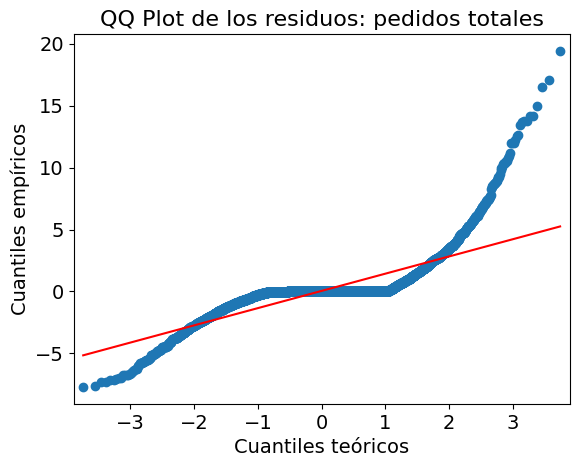

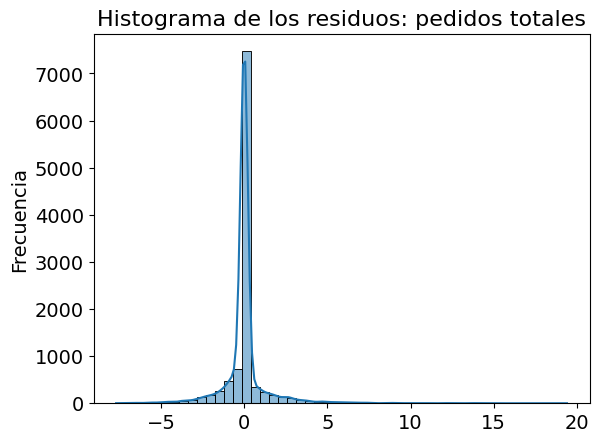

In [174]:
# Serie de pedidos totales
y_real = df_hyb_lig_res_ts["tot_test_true"]
y_pred = df_hyb_lig_res_ts["tot_test_predict"]

# Residuos
residuals = y_real - y_pred

# QQ-Plot
sm.qqplot(residuals, line="s")
plt.title("QQ Plot de los residuos: pedidos totales", fontsize=16)
plt.xlabel("Cuantiles teóricos", fontsize=14)
plt.ylabel("Cuantiles empíricos", fontsize=14)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)
plt.show()

# Histograma
sns.histplot(residuals, kde=True, bins=50)
plt.title("Histograma de los residuos: pedidos totales", fontsize=16)
plt.ylabel("Frecuencia", fontsize=14)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)
plt.show()

In [175]:
# Adherir las features X que originan las predicciones
cols_to_add = list(set(tree_feature_cols_light).difference(["hora", "tramo", "abierto_tarde", "abierto_noche"]))
X = df_hyb_lig_res_ts.join(df_tree_oh[cols_to_add], on="index")[tree_feature_cols_light]
X = sm.add_constant(X, has_constant="add")

# Prueba de White
lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(residuals, X)
print({
    "LM Statistic": lm_stat,
    "LM-Test p-value": lm_pvalue,
    "F-Statistic": f_stat,
    "F-Test p-value": f_pvalue
})

{'LM Statistic': 3722.793939316375, 'LM-Test p-value': 0.0, 'F-Statistic': 6.932928465250949, 'F-Test p-value': 0.0}


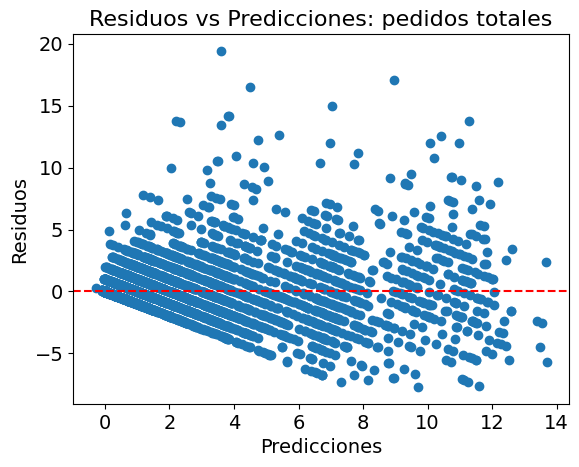

In [176]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--") # Valor ideal
plt.title("Residuos vs Predicciones: pedidos totales", fontsize=16)
plt.xlabel("Predicciones", fontsize=14)
plt.ylabel("Residuos", fontsize=14)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)
plt.show()

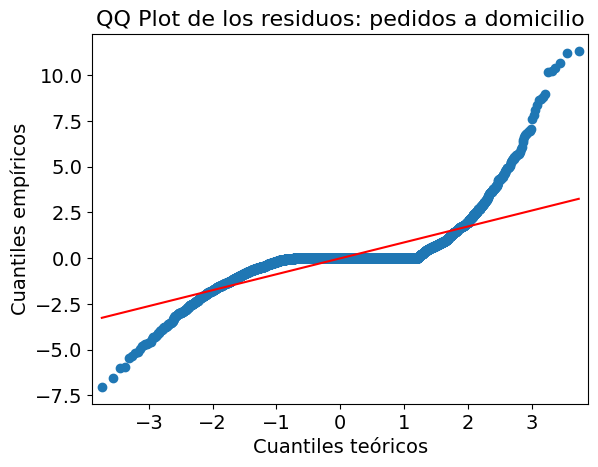

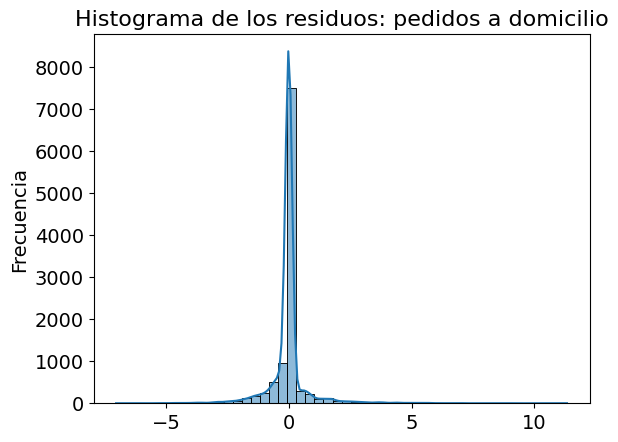

In [177]:
# Serie de pedidos a domicilio
y_real = df_hyb_lig_res_ts["dom_test_true"]
y_pred = df_hyb_lig_res_ts["dom_test_predict"]

# Residuos
residuals = y_real - y_pred

# QQ-Plot
sm.qqplot(residuals, line="s")
plt.title("QQ Plot de los residuos: pedidos a domicilio", fontsize=16)
plt.xlabel("Cuantiles teóricos", fontsize=14)
plt.ylabel("Cuantiles empíricos", fontsize=14)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)
plt.show()

# Histograma
sns.histplot(residuals, kde=True, bins=50)
plt.title("Histograma de los residuos: pedidos a domicilio", fontsize=16)
plt.ylabel("Frecuencia", fontsize=14)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)
plt.show()

In [178]:
# Prueba de White
lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(residuals, X)
print({
    "LM Statistic": lm_stat,
    "LM-Test p-value": lm_pvalue,
    "F-Statistic": f_stat,
    "F-Test p-value": f_pvalue
})

{'LM Statistic': 4182.741491165125, 'LM-Test p-value': 0.0, 'F-Statistic': 8.334866879589807, 'F-Test p-value': 0.0}


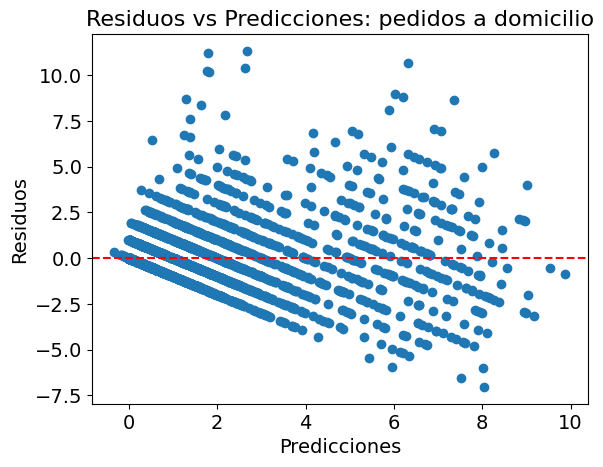

In [179]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--") # Valor ideal
plt.title("Residuos vs Predicciones: pedidos a domicilio", fontsize=16)
plt.xlabel("Predicciones", fontsize=14)
plt.ylabel("Residuos", fontsize=14)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)
plt.show()

En ambos casos, los histogramas muestran una distribución de residuos fuertemente concentrada en torno a 0, lo que indica que el modelo reproduce correctamente la gran mayoría de las observaciones. Sin embargo, los QQ-Plots evidencian desviaciones significativas respecto a la normalidad en los extremos superiores. Esto sugiere una ligera asimetría positiva, es decir, el modelo tiende a subestimar los valores más altos, generando residuos positivos en los picos de demanda.

Los diagramas de residuos frente a predicciones confirman este patrón: la dispersión crece con el nivel de predicción, especialmente en valores altos, indicando heterocedasticidad. Este resultado respalda la prueba de White, cuyo p-valor inferior a 0.05 rechaza la hipótesis nula de homocedasticidad. En consecuencia, puede concluirse que la varianza de los errores no es constante, sino que depende del nivel de predicción—y probablemente también de ciertos momentos del tiempo asociados a mayor demanda—.

## 3. Conclusiones

El estudio demuestra la viabilidad de modelar la demanda de un negocio hostelero español mediante técnicas de aprendizaje automático y series temporales. Entre los modelos evaluados, el enfoque **híbrido**—basado en *LightGBM* combinado con una media móvil estacional—ofrece el mejor equilibrio entre precisión y consistencia, con un rendimiento comparable o superior al de modelos más complejos.  

Se observa que las variables climatológicas y macroeconómicas aportan un valor predictivo limitado, por lo que el modelo puede operar eficazmente utilizando solo información interna del negocio y el calendario de festivos y fútbol. Además, la validación cruzada temporal con **ventanas crecientes** mejora la capacidad de generalización del modelo.  

Entre las limitaciones se identifican la dificultad para capturar picos extremos de demanda y la posible variabilidad inherente a los procesos de entrenamiento. Como línea futura, se propone incorporar técnicas específicas para la predicción de valores atípicos y explorar modelos probabilísticos que cuantifiquen la incertidumbre de las predicciones.  